# Detección de outliers Mediante Autoencoders

Alejandro Gil Villar

# Librerías

In [1]:
# Cargamos las librerías y funciones necesarias
import pandas as pd
import numpy as np
import tensorflow as tf
import os

from scipy.stats import gaussian_kde


# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías relacionadas con SKLearn
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, f1_score
from sklearn.decomposition import PCA

# Librerías relacionadas con Keras y redes neuronales
from keras import layers
from keras.layers import Input, Dense, Lambda
from keras.models import Model, Sequential
from keras import regularizers
from tensorflow.keras.callbacks import Callback

# Librerías relacionadas con Tensorflow
from tensorflow.keras import losses
from tensorflow.keras.regularizers import l2, l1, l1_l2
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import binary_crossentropy, mse
from tensorflow.keras import backend as K

# Para generación de números aleatorios
import random as rn

# imbalanced-learn
from imblearn.over_sampling import SMOTE

# Semilla aleatoria
RANDOM_SEED = 10
VALIDATE_SIZE = 0.2

# Establecer semillas aleatorias para librerías para asegurar reproducibilidad
np.random.seed(RANDOM_SEED)
rn.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Para evitar warnings
import warnings

warnings.filterwarnings("ignore")

# Introducción

### Objetivo del Trabajo

El objetivo de este proyecto es abordar el desafío de la detección de fraude en el sector financiero, utilizando para ello técnicas avanzadas de aprendizaje automático, con un enfoque particular en los Autoencoders. Nuestro propósito es discernir transacciones fraudulentas de las legítimas dentro de volúmenes grandes de operaciones, con el fin de incrementar la seguridad y confianza en el ecosistema financiero.

### Importancia del Problema

El fraude financiero constituye una amenaza considerable, causando cada año importantes pérdidas económicas a individuos y entidades, y erosionando la confianza en el sistema financiero. Con la prevalencia de las transacciones electrónicas en la actualidad, es imperativo contar con mecanismos eficaces para la detección y prevención del fraude. Este trabajo no solo busca mitigar el impacto económico adverso del fraude sino también salvaguardar a los consumidores y preservar la estabilidad y confiabilidad del sistema financiero.

### Motivación para Utilizar Autoencoders en la Detección de Fraudes

Los Autoencoders son destacados por su habilidad para aprender representaciones comprimidas y significativas de los datos, lo cual es particularmente útil en la identificación de anomalías o patrones inusuales en transacciones financieras. A través de la reconstrucción de los datos de entrada, los Autoencoders facilitan la distinción entre las transacciones normales y las potencialmente fraudulentas, basándose en las discrepancias entre los datos originales y sus reconstrucciones. Esta capacidad los convierte en herramientas valiosas para detectar fraudes de manera eficiente, adaptándose a la naturaleza cambiante y sofisticada del fraude financiero, y proporcionando una solución robusta sin la necesidad de supervisión explícita.

### Desafíos y Soluciones Propuestas

Dada la complejidad y el volumen de datos financieros, identificar patrones de fraude implica superar varios desafíos, incluyendo el desbalance entre clases, la evolución constante de las tácticas fraudulentas y la necesidad de minimizar los falsos positivos para evitar inconvenientes a usuarios legítimos. En este trabajo, exploramos cómo los Autoencoders, particularmente a través de su capacidad de aprendizaje no supervisado, pueden ofrecer soluciones innovadoras a estos retos, permitiendo una detección más precisa y dinámica del fraude.

### Contribuciones del Trabajo

Este proyecto contribuye al campo de la detección de fraude financiero mediante la implementación y evaluación de modelos de Autoencoders, comparándolos con técnicas convencionales como PCA y detallando su rendimiento en un conjunto de datos real de transacciones financieras. Además, proponemos mejoras en la arquitectura de los modelos y en las estrategias de entrenamiento para optimizar su capacidad de identificar transacciones fraudulentas, ofreciendo así un marco de trabajo replicable y escalable para futuras investigaciones y aplicaciones prácticas en la lucha contra el fraude financiero.


# Descripción de los Datos Utilizados

### Contexto del Conjunto de Datos

El conjunto de datos analizado en este estudio proviene de transacciones con tarjetas de crédito realizadas en septiembre de 2013 por titulares europeos. Esta base de datos es fundamental para desarrollar y probar nuestros modelos de detección de fraude, ya que incluye ejemplos tanto de operaciones legítimas como fraudulentas, permitiéndonos entrenar algoritmos que puedan identificar patrones sospechosos eficazmente.

### Características del Conjunto de Datos

- **Tiempo (Time):** Representa el intervalo de tiempo entre cada transacción y la primera transacción en el conjunto de datos, medida en segundos. Esta variable puede ayudar a identificar patrones temporales relacionados con el fraude.

- **Variables PCA (V1-V28):** Para proteger la confidencialidad de los usuarios, las características originales han sido transformadas utilizando Análisis de Componentes Principales (PCA). Estas 28 variables resultantes son las principales componentes identificadas por PCA y no están directamente relacionadas con los atributos originales de las transacciones.

- **Cantidad (Amount):** Esta variable indica el monto de dinero involucrado en cada transacción. La distribución de montos puede variar ampliamente, desde pequeñas compras hasta grandes transferencias, y es un factor clave en la detección de actividades fraudulentas.

- **Clase (Class):** La etiqueta de cada transacción, donde `0` indica una transacción legítima y `1` señala una transacción fraudulenta. Esta variable binaria es esencial para el entrenamiento supervisado de nuestros modelos y para evaluar su capacidad para clasificar correctamente las transacciones.



In [109]:
# Cargamos el dataset
df = pd.read_csv('creditcard.csv')

# Mostramos información básica
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

#### Mostramos las primeras filas

In [110]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### Generamos estadísticas descriptivas sobre las columnas numéricas

In [111]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## Gráficos para la visualización de los datos

### Distribución de Clases

Muestra las clases únicas presentes en el conjunto de datos. Esto proporciona una visión rápida de las diferentes categorías o etiquetas disponibles en los datos.



Unique classes in the dataset are : [0 1]


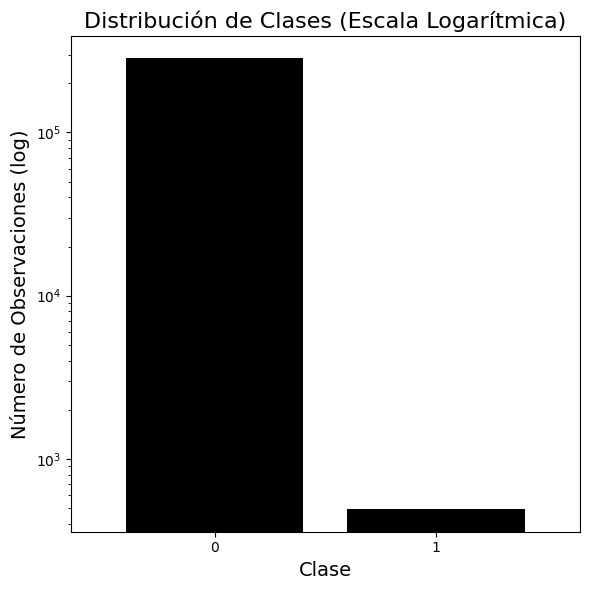

In [112]:
# Mostramos las clases únicas en el conjunto de datos
print(f"Unique classes in the dataset are : {np.unique(df['Class'])}")

# Creamos un gráfico de barras
plt.figure(figsize=(6, 6))
df.groupby('Class')['Class'].count().plot.bar(logy=True, color='black', width=0.8)

# Estilizamos el gráfico
plt.title('Distribución de Clases (Escala Logarítmica)', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Número de Observaciones (log)', fontsize=14)
plt.xticks(rotation=0)

# Mostramos el gráfico
plt.tight_layout()
plt.show()


Gracias a este histograma, podemos visualizar claramente la disparidad en el número de observaciones entre las dos clases presentes en nuestro conjunto de datos. La mayor parte de las transacciones registradas son de naturaleza normal, mientras que un pequeño porcentaje corresponden a transacciones fraudulentas.

### Distribución de Transacciones a lo Largo del Tiempo

Este código genera un histograma para visualizar cómo se distribuyen las transacciones a lo largo del tiempo en el conjunto de datos:


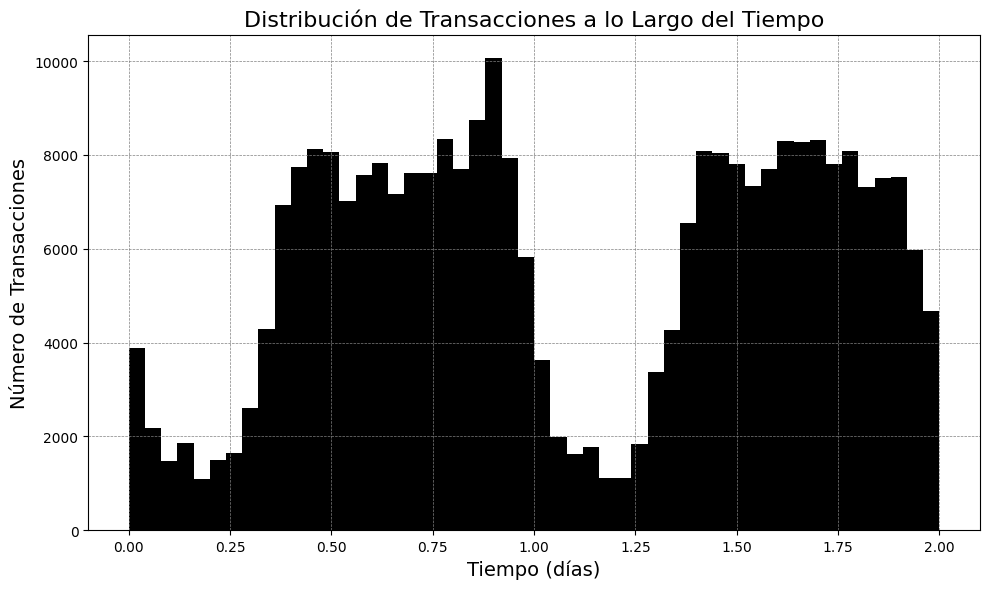

In [113]:
# Creamos un histograma para visualizar la distribución de transacciones a lo largo del tiempo
plt.figure(figsize=(10, 6))
plt.hist(df['Time'] / (60 * 60 * 24), bins=50, color='black')

# Estilizamos el gráfico
plt.title('Distribución de Transacciones a lo Largo del Tiempo', fontsize=16)
plt.xlabel('Tiempo (días)', fontsize=14)
plt.ylabel('Número de Transacciones', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey')

# Mostramos el histograma
plt.tight_layout()
plt.show()



En este histograma se evidencian los picos en la frecuencia de las transacciones a lo largo del tiempo. Se observa que tanto al inicio como al final de cada día el número de transacciones es menor en comparación con las horas centrales del día.

### Distribución de Montos de Transacciones

Este código produce un histograma para explorar cómo se distribuyen los montos de las transacciones en el conjunto de datos, complementado con una estimación de densidad de kernel (KDE) para visualizar la distribución de manera suavizada:


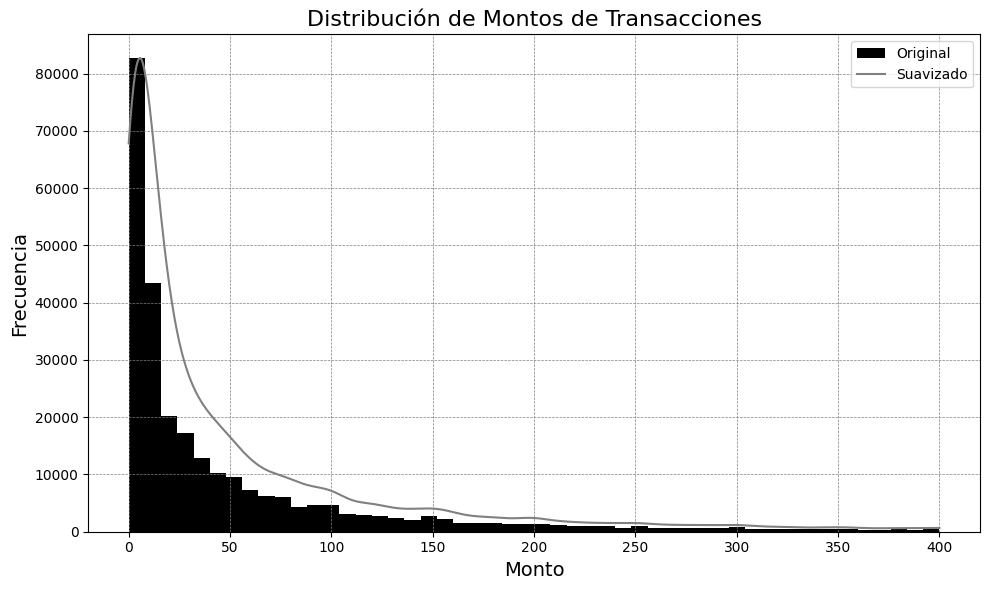

In [114]:
# Creamos un histograma para visualizar la distribución de montos de transacciones
plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(df['Amount'], bins=50, color='black', label='Original', range=(0,400))

# Calculamos la densidad de KDE (Kernel Density Estimation)
kde = gaussian_kde(df['Amount'])
kde.set_bandwidth(bw_method=kde.factor / 3.)

# Generamos valores en el rango para la línea de densidad suavizada
x_range = np.linspace(0, 400, 1000)

# Dibujamos la línea de densidad suavizada
plt.plot(x_range, kde(x_range) * count.max() / kde(x_range).max(), color='grey', label='Suavizado')

# Estilizamos el gráfico
plt.title('Distribución de Montos de Transacciones', fontsize=16)
plt.xlabel('Monto', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey')

# Mostramos el histograma con la línea suavizada
plt.tight_layout()
plt.show()


En este histograma se destaca que la mayoría de las transacciones realizadas corresponden a montos relativamente pequeños. Se observa claramente que las primeras barras son significativamente más altas en comparación con las siguientes, lo que indica una mayor frecuencia de transacciones con montos bajos en contraste con aquellas de montos más elevados.

## Preprocesamiento de Datos para el Análisis de Fraude

Este conjunto de operaciones prepara los datos para un análisis de fraude eficiente, mediante la aplicación de transformaciones específicas a las variables temporales y de montos de transacciones:

#### Conversión del Atributo Temporal de segundos a Días
- **Transformación de `Time`**: Convertimos la característica `Time` de segundos a dias usando la fórmula `(t / 3600) % 24`. Esta adaptación permite la detección de patrones de transacciones diarios, facilitando la identificación de actividades fraudulentas que pueden variar según el momento del día.

#### Ajuste de la Variable `Amount`
- **Modificación en `Amount`**: Para evitar calcular el logaritmo de cero, agregamos un valor mínimo (0.00001) a `Amount` antes de su transformación logarítmica. Este procedimiento mantiene la continuidad de la operación sin alterar significativamente la información de los montos.

- **Transformación Logarítmica**: Aplicamos una transformación logarítmica a la característica `Amount` para reducir su sesgo y distribuir más uniformemente sus valores. Esto puede ayudar al modelo a aprender de manera más efectiva patrones en la cantidad de transacciones, especialmente cuando hay una gran variabilidad en los montos.

#### Reestructuración del Conjunto de Datos
- **Reorganización de Columnas**: Para una mejor legibilidad y manejo, `log10_amount` y `Class` se mueven al final del DataFrame.

- **Eliminación de Características Redundantes**: Tras generar `log10_amount`, eliminamos la columna original `Amount` para enfocarnos en los datos transformados que resultan más útiles para el modelado.


In [115]:
# Convertimos el atributo de tiempo a horas del día
df['Time'] = df['Time'].apply(lambda t: (t/3600) % 24)

# Añadimos una cantidad insignificante para evitar tomar el logaritmo de 0
df['log10_amount'] = np.log10(df.Amount + 0.00001)

# Movemos el campo 'Class' al final del DataFrame
df = df[
    [col for col in df if col not in ['Class', 'log10_amount']] +
    ['log10_amount', 'Class']
]

# Eliminamos la columna 'Amount'
df = df.drop(['Amount'], axis=1)

# Mostramos estadísticas descriptivas del DataFrame
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,log10_amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,14.537951,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,1.264716,0.001727
std,5.847061,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,0.953123,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,-5.000000,0.000000
25%,10.598194,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,0.748189,0.000000
50%,15.010833,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,1.342423,0.000000
75%,19.329722,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,1.887420,0.000000
max,23.999444,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,4.409784,1.000000



# División en Entrenamiento/Validación/Test

### 1. **División por Clase**:
- **Objetivo**: Separar el conjunto de datos en dos grupos según la clase: transacciones fraudulentas (`Class == 1`) y transacciones no fraudulentas (`Class == 0`).


In [116]:
# Dividir por clase
fraud = df[df.Class == 1]
clean = df[df.Class == 0]

In [117]:
print(f"""Shape of the datasets:
    clean (rows, cols) = {clean.shape}
    fraud (rows, cols) = {fraud.shape}""")

Shape of the datasets:
    clean (rows, cols) = (284315, 31)
    fraud (rows, cols) = (492, 31)


## Division sin Balanceo de Clases
Nuestro autoencoder solo se entrenará con transacciones que sean normales y se validará con un 10% de las transacciones fraudulentas y transacciones normales.
Lo que quede se utilizará para formar nuestro conjunto de test.


- Entrenamiento:
    * Dividido en:
        1. Entrenamiento real de nuestro autoencoder con transacciones normales
        2. Validación de la capacidad de generalización de la red neuronal con transacciones normales y un 10% de las fraudulentas
            * Intentar localizar valores atípicos
                1. Calcular la pérdida de reconstrucción
                2. Aplicar un umbral
- Test: mezcla de fraudes y no fraudes
    * Tratado como nuevos datos

### 2. **Mezcla de Datos No Fraudulentos**:
- **Razón**: Mezclamos las transacciones no fraudulentas para garantizar una distribución aleatoria, evitando cualquier sesgo potencial en el conjunto de entrenamiento.

### 3. **Creación de Conjuntos de Entrenamiento y Validación**:
- **Método**: Dividimos las transacciones no fraudulentas en conjuntos de entrenamiento y validación con `train_test_split`, lo que facilita una evaluación objetiva del modelo.

### 4. **Asignación de Transacciones Fraudulentas para Validación y Pruebas**:
- **Distribución**: Reservamos el 10% de las transacciones fraudulentas para la validación, garantizando que el modelo sea probado contra ejemplos de fraude no vistos durante el entrenamiento.

### 5. **Combinación de Conjuntos de Datos**:
- **Finalidad**: Integrar transacciones fraudulentas y no fraudulentas en los conjuntos de prueba y validación para crear una representación realista de los datos operacionales.


In [118]:
# Mezclar el conjunto de entrenamiento
clean = clean.sample(frac=1).reset_index(drop=True)

# Dividir el conjunto limpio en entrenamiento y test
X_train, X_test_clean = train_test_split(clean, test_size=VALIDATE_SIZE, random_state=RANDOM_SEED)

X_train, X_validate = train_test_split(X_train, test_size=VALIDATE_SIZE, random_state=RANDOM_SEED)

# Dividir los datos de fraude para test y validate
fraud_test, fraud_validate = train_test_split(fraud, test_size=0.1, random_state=RANDOM_SEED)  # El 10% de fraude va a validate

# Añadir transacciones fraudulentas al conjunto de test y mezclar
X_test = pd.concat([X_test_clean, fraud_test]).sample(frac=1).reset_index(drop=True)

# Añadir el 10% de las transacciones fraudulentas al conjunto de validate y mezclar
X_validate = pd.concat([X_validate, fraud_validate]).sample(frac=1).reset_index(drop=True)

## División con Balanceo de Clases (SMOTE)

En este segundo enfoque, se plantea una estrategia distinta: en lugar de entrenar únicamente con transacciones normales, se construye un conjunto de entrenamiento balanceado que incluye tanto transacciones normales como fraudulentas. Para ello, se utiliza la técnica de sobremuestreo sintético **SMOTE (Synthetic Minority Oversampling Technique)**, que genera ejemplos sintéticos de la clase minoritaria (fraude) con el fin de reducir el desbalance de clases.

### 1. Preparación de los Datos Normales y Fraudulentos
- **Normalización de las transacciones normales**: se mezclan aleatoriamente las transacciones no fraudulentas para evitar cualquier sesgo en el orden de los registros.  
- **División del dataset**: se utilizan particiones `train_test_split` para crear conjuntos de entrenamiento, validación y prueba tanto para transacciones normales como para las fraudulentas. De esta manera, cada subconjunto contiene ejemplos de ambas clases.  

### 2. Construcción del Conjunto de Entrenamiento Combinado
- Se unen las transacciones normales y fraudulentas correspondientes al entrenamiento.  
- Se crea un **vector de etiquetas** asociado, donde `0` indica transacciones normales y `1` indica transacciones fraudulentas.  
- En este punto, el conjunto de entrenamiento refleja la desproporción natural entre las clases, siendo necesario aplicar técnicas de balanceo.  

### 3. Aplicación de SMOTE para Balanceo
- **Objetivo**: conseguir una proporción aproximada de **70% transacciones normales y 30% fraudulentas** en el conjunto de entrenamiento.  
- **Estrategia**:  
  - La clase mayoritaria (transacciones normales) se mantiene intacta.  
  - La clase minoritaria (fraudes) se incrementa artificialmente mediante la generación de nuevos ejemplos sintéticos hasta alcanzar el número necesario de instancias definido por la proporción deseada.  

### 4. Validación del Balance
- Se imprime la distribución de clases antes y después de aplicar **SMOTE**, lo que permite confirmar que se ha alcanzado la relación buscada.  
- El resultado es un conjunto de entrenamiento equilibrado que facilita el aprendizaje del modelo, reduciendo el riesgo de sesgo hacia la clase mayoritaria.  

### 5. Preparación de Conjuntos de Validación y Test
- Finalmente, se integran transacciones fraudulentas reales en los conjuntos de validación y prueba.  
- Estos se mezclan de forma aleatoria para simular un entorno realista en el que el modelo debe enfrentarse a un flujo heterogéneo de transacciones normales y fraudulentas.  


In [119]:
# Mezclar el conjunto de transacciones normales
clean = clean.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Dividir el conjunto de transacciones normales en training, validación y test
X_train_v2, X_test_v2 = train_test_split(clean, test_size=VALIDATE_SIZE, random_state=RANDOM_SEED)
X_train_v2, X_validate_v2 = train_test_split(X_train_v2, test_size=VALIDATE_SIZE, random_state=RANDOM_SEED)

# Dividir los datos de fraude para train, validate, test
fraud_train_v2, fraud_test_v2 = train_test_split(fraud, test_size=VALIDATE_SIZE, random_state=RANDOM_SEED)
fraud_train_v2, fraud_validate_v2 = train_test_split(fraud_train_v2, test_size=VALIDATE_SIZE, random_state=RANDOM_SEED)

# Combinar los datos para el conjunto de entrenamiento:
# Se unen los registros normales (X_train_v2) y los fraudes asignados a training.
X_train_combined_v2 = pd.concat([X_train_v2, fraud_train_v2]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
# Crear el vector de etiquetas: 0 para normales (correspondiente a X_train_v2) y 1 para fraudes (fraud_train_v2)
y_train_v2 = np.concatenate([np.zeros(len(X_train_v2)), np.ones(len(fraud_train_v2))])

# Verificar la distribución original en training (antes de balancear)
print("Antes de SMOTE, distribución en training:")
print(pd.Series(y_train_v2).value_counts())

# Para lograr una relación 70/30 (normales/fraudes) en training:
target_fraud_count = int((3/7) * len(X_train_v2))

# Definir la estrategia de SMOTE: dejar intacta la clase 0 (normales) y oversamplear la clase 1 (fraudes) hasta target_fraud_count
smote_strategy = {0: len(X_train_v2), 1: target_fraud_count}

sm = SMOTE(sampling_strategy=smote_strategy, random_state=RANDOM_SEED)
# ¡IMPORTANTE! Usar el conjunto combinado para que X e y tengan el mismo número de muestras.
X_train_bal, y_train_bal = sm.fit_resample(X_train_combined_v2, y_train_v2)

# Convertir el resultado a DataFrame y agregar la columna 'Class'
X_train_v2 = pd.DataFrame(X_train_bal, columns=X_train_combined_v2.columns)
X_train_v2['Class'] = y_train_bal

# Verificar la nueva distribución en training después de SMOTE
print("\nDespués de SMOTE, distribución en training:")
print(X_train_v2.Class.value_counts())

# Añadir transacciones fraudulentas al conjunto de test y mezclar
X_test_v2 = pd.concat([X_test_v2, fraud_test_v2]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Añadir transacciones fraudulentas al conjunto de validación y mezclar
X_validate_v2 = pd.concat([X_validate_v2, fraud_validate_v2]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


Antes de SMOTE, distribución en training:
0.0    181961
1.0       314
Name: count, dtype: int64

Después de SMOTE, distribución en training:
Class
0.0    181961
1.0     77983
Name: count, dtype: int64


### 6. **Visualización y Balance de Clases**:
- **Verificación**: Observamos la distribución de clases en cada conjunto para confirmar un balance adecuado, crucial para un entrenamiento efectivo.


In [120]:
print(f"""Sin Balanceo de Datos:
    training (rows, cols) = {X_train.shape}
    validate (rows, cols) = {X_validate.shape}
    test  (rows, cols) = {X_test.shape}""")

Sin Balanceo de Datos:
    training (rows, cols) = (181961, 31)
    validate (rows, cols) = (45541, 31)
    test  (rows, cols) = (57305, 31)


In [121]:
print(f"""Balanceo de Datos:
    training (rows, cols) = {X_train_v2.shape}
    validate (rows, cols) = {X_validate_v2.shape}
    test  (rows, cols) = {X_test_v2.shape}""")

Balanceo de Datos:
    training (rows, cols) = (259944, 31)
    validate (rows, cols) = (45570, 31)
    test  (rows, cols) = (56962, 31)


In [122]:
print(f"""Sin Balanceo de Datos \nOur Trainging set is composed as follows:

{X_train.Class.value_counts()}""")

print(f"""\nOur Validating set is composed as follows:

{X_validate.Class.value_counts()}""")

print(f"""\nOur testing set is composed as follows:

{X_test.Class.value_counts()}""")

Sin Balanceo de Datos 
Our Trainging set is composed as follows:

Class
0    181961
Name: count, dtype: int64

Our Validating set is composed as follows:

Class
0    45491
1       50
Name: count, dtype: int64

Our testing set is composed as follows:

Class
0    56863
1      442
Name: count, dtype: int64


In [123]:
print(f"""\n Balanceo de Datos: \nOur Trainging set is composed as follows:

{X_train_v2.Class.value_counts()}""")

print(f"""\nOur Validating set is composed as follows:

{X_validate_v2.Class.value_counts()}""")

print(f"""\nOur testing set is composed as follows:

{X_test_v2.Class.value_counts()}""")


 Balanceo de Datos: 
Our Trainging set is composed as follows:

Class
0.0    181961
1.0     77983
Name: count, dtype: int64

Our Validating set is composed as follows:

Class
0    45491
1       79
Name: count, dtype: int64

Our testing set is composed as follows:

Class
0    56863
1       99
Name: count, dtype: int64


### 7. **Preparación de las Características y Etiquetas**:
- **Extracción de Etiquetas**:
    1. Separamos las etiquetas de clase de los conjuntos de datos.

    2. Eliminamos la columna `Class` de los conjuntos de características para entrenar los modelos únicamente con datos de entrada.


In [124]:
# Obtener las etiquetas de clase para entrenamiento, validación y test
y_train, y_validate, y_test = X_train.Class.values, X_validate.Class.values, X_test.Class.values

# Eliminar la columna 'Class' de los conjuntos de entrenamiento, validación y test
X_train = X_train.drop('Class', axis=1)
X_validate = X_validate.drop('Class', axis=1)
X_test = X_test.drop('Class', axis=1)

In [125]:
# Obtener las etiquetas de clase para entrenamiento, validación y test
y_train_v2, y_validate_v2, y_test_v2 = X_train_v2.Class.values, X_validate_v2.Class.values, X_test_v2.Class.values 

# Eliminar la columna 'Class' de los conjuntos de entrenamiento, validación y test
X_train_v2 = X_train_v2.drop('Class', axis=1)
X_validate_v2 = X_validate_v2.drop('Class', axis=1)
X_test_v2 = X_test_v2.drop('Class', axis=1)

# Normalización de Datos con MinMaxScaler

Para optimizar el rendimiento de los modelos de aprendizaje automático en el análisis de fraude, aplicamos un proceso de normalización utilizando MinMaxScaler. Este proceso involucra los siguientes pasos clave:

### 1. **Inicialización de MinMaxScaler:**
Inicializamos MinMaxScaler para escalar las características dentro de un rango predeterminado, generalmente entre 0 y 1. Este paso prepara el escalador para ajustarse a los datos de entrenamiento y asegura una transformación uniforme de todos los conjuntos de datos.

### 2. **Ajuste de MinMaxScaler con Datos de Entrenamiento:**
El escalador se ajusta con el conjunto de entrenamiento para determinar los valores mínimos y máximos de cada característica. Este ajuste permite establecer los parámetros necesarios para la normalización, asegurando transformaciones coherentes en todos los datos.

In [126]:
# Creamos una instancia del escalador MinMaxScaler
min_max_scaler = MinMaxScaler()

# Ajustamos el escalador a los datos de entrenamiento
min_max_scaler.fit(X_train)

MinMaxScaler()

In [127]:
# Creamos una instancia del escalador MinMaxScaler
min_max_scaler_v2 = MinMaxScaler()

# Ajustamos el escalador a los datos de entrenamiento
min_max_scaler_v2.fit(X_train_v2)

MinMaxScaler()

### 3. **Transformación de Conjuntos de Entrenamiento y Validación:**
Los conjuntos de entrenamiento y validación se transforman utilizando los parámetros ajustados. Esta normalización facilita el aprendizaje del modelo y mejora la precisión, al hacer que las características de diferentes magnitudes sean directamente comparables.

### 4. **Transformación del Conjunto de Prueba:**
El conjunto de prueba se transforma utilizando los mismos parámetros de escala ajustados previamente. Esto garantiza que se normalice de manera idéntica a los conjuntos de entrenamiento y validación, permitiendo evaluaciones precisas del rendimiento del modelo en datos no vistos.


In [128]:
# Utilizamos los parámetros aprendidos por el escalador MinMaxScaler para normalizar los conjuntos de entrenamiento y validación.
X_train_transformed = min_max_scaler.transform(X_train)
X_validate_transformed = min_max_scaler.transform(X_validate)

# Transformamos el conjunto de prueba
X_test_transformed = min_max_scaler.transform(X_test)

In [129]:
# Utilizamos los parámetros aprendidos por el escalador MinMaxScaler para normalizar los conjuntos de entrenamiento y validación.
X_train_transformed_v2 = min_max_scaler_v2.transform(X_train_v2)
X_validate_transformed_v2 = min_max_scaler_v2.transform(X_validate_v2)

# Transformamos el conjunto de prueba
X_test_transformed_v2 = min_max_scaler_v2.transform(X_test_v2)

# Función de Curvas del Entrenamiento

La función `plot_training_history` está diseñada para proporcionar una visión exhaustiva del proceso de entrenamiento de un modelo, visualizando la evolución de tres métricas claves: el `loss` (pérdida), la `acc` (precisión) y el `mse` (error cuadrático medio). Estas métricas se presentan tanto para el conjunto de entrenamiento como para el de validación. Aquí se detalla la estructura y propósito de cada parte de la función:

1. **Configuración de la Figura:** Se establece un tamaño de figura grande (12x10) para acomodar todos los gráficos de manera clara y legible.

2. **Evolución del Loss:** El primer gráfico muestra cómo el `loss` y el `val_loss` cambian a lo largo de todas las épocas. Esta visualización es fundamental para entender cómo el modelo está aprendiendo y si está sufriendo de sobreajuste o subajuste.

3. **Evolución de la Precisión:** El segundo gráfico muestra la trayectoria de la `acc` y `val_acc` a través de las épocas, proporcionando una visión de cómo la capacidad del modelo para clasificar correctamente los datos mejora con el entrenamiento.

4. **Evolución del MSE:** El tercer gráfico presenta el `mse` y `val_mse`, ofreciendo otra dimensión de evaluación del rendimiento del modelo, particularmente útil en tareas de regresión o en donde se busca minimizar la diferencia cuadrada.

5. **Foco en las Últimas 100 Épocas para el Loss:** El cuarto gráfico se centra en las últimas 100 épocas para el `loss` y `val_loss`, proporcionando una vista detallada de la convergencia del modelo hacia el final del entrenamiento.

6. **Foco en las Últimas 100 Épocas para la Precisión:** De manera similar, el quinto gráfico enfoca en la precisión (`acc` y `val_acc`) durante las últimas 100 épocas, permitiendo una inspección más cercana de las mejoras o cambios finales en la capacidad predictiva del modelo.

7. **Foco en las Últimas 100 Épocas para el MSE:** El sexto y último gráfico muestra el `mse` y `val_mse` en las últimas 100 épocas, brindando insights sobre cómo el error cuadrático medio se estabiliza o varía en la fase final del entrenamiento.

8. **Visualización y Organización:** Cada gráfico incorpora leyendas para diferenciar entre los datos de entrenamiento y validación. La disposición de los subgráficos se ajusta para evitar superposiciones y garantizar una interpretación clara de los datos.


In [70]:
def plot_training_history(hist):
    # Configuramos el tamaño de la figura
    plt.figure(figsize=(12, 10))

    # Gráfico superior para la evolución del loss
    plt.subplot(2, 3, 1)
    plt.plot(hist.history['loss'], label="loss")
    plt.plot(hist.history['val_loss'], label="val_loss")
    plt.title("Evolución del Loss Durante el Entrenamiento")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()

    # Gráfico superior para la evolución de la métrica de precisión
    plt.subplot(2, 3, 2)
    plt.plot(hist.history['acc'], label="acc")
    plt.plot(hist.history['val_acc'], label="val_acc")
    plt.title("Evolución de la Precisión Durante el Entrenamiento")
    plt.xlabel("Épocas")
    plt.ylabel("Precisión")
    plt.legend()

    # Gráfico superior para la evolución del MSE
    plt.subplot(2, 3, 3)
    plt.plot(hist.history['mse'], label="mse")
    plt.plot(hist.history['val_mse'], label="val_mse")
    plt.title("Evolución del MSE Durante el Entrenamiento")
    plt.xlabel("Épocas")
    plt.ylabel("MSE")
    plt.legend()

    # Selección de las últimas 100 épocas para los gráficos inferiores
    epochs_shown = 100
    epochs = range(len(hist.history['loss']))
    last_epochs = list(epochs)[-epochs_shown:]

    # Gráfico inferior para la evolución del loss en las últimas 100 épocas
    plt.subplot(2, 3, 4)
    plt.plot(last_epochs, hist.history['loss'][-epochs_shown:], label="loss")
    plt.plot(last_epochs, hist.history['val_loss'][-epochs_shown:], label="val_loss")
    plt.title("Loss en las Últimas 100 Épocas")
    plt.xlabel("Últimas Épocas")
    plt.ylabel("Loss")
    plt.legend()

    # Gráfico inferior para la evolución de la métrica de precisión en las últimas 100 épocas
    plt.subplot(2, 3, 5)
    plt.plot(last_epochs, hist.history['acc'][-epochs_shown:], label="acc")
    plt.plot(last_epochs, hist.history['val_acc'][-epochs_shown:], label="val_acc")
    plt.title("Precisión en las Últimas 100 Épocas")
    plt.xlabel("Últimas Épocas")
    plt.ylabel("Precisión")
    plt.legend()

    # Gráfico inferior para la evolución del MSE en las últimas 100 épocas
    plt.subplot(2, 3, 6)
    plt.plot(last_epochs, hist.history['mse'][-epochs_shown:], label="mse")
    plt.plot(last_epochs, hist.history['val_mse'][-epochs_shown:], label="val_mse")
    plt.title("MSE en las Últimas 100 Épocas")
    plt.xlabel("Últimas Épocas")
    plt.ylabel("MSE")
    plt.legend()

    # Mostrar los gráficos
    plt.tight_layout()
    plt.show()


## Función para representar el entrenamiento del mejor modelo

La función `plot_training_history_saves` está diseñada para visualizar la evolución del proceso de entrenamiento de un modelo, enfocándose en dos métricas clave: el `loss` (pérdida) y la `acc` (precisión). Estas métricas se presentan tanto para el conjunto de entrenamiento como para el conjunto de validación. La función se estructura de la siguiente manera:

1. **Configuración del Tamaño de la Figura:** Se establece un tamaño adecuado para la figura que contendrá los gráficos, asegurando que haya espacio suficiente para una visualización clara de la información.

2. **Gráfico de la Evolución del Loss:** El primer subplot muestra cómo el `loss` y el `val_loss` (loss de validación) cambian a lo largo de todas las épocas de entrenamiento. Esto proporciona una visión general de la convergencia del modelo y ayuda a identificar si el modelo está sobreajustando (overfitting) o subajustando (underfitting).

3. **Gráfico de la Evolución de la Precisión:** El segundo subplot muestra la precisión (`acc`) y la precisión de validación (`val_acc`) a lo largo de todas las épocas. Esta visualización es crucial para entender cómo la capacidad del modelo para clasificar correctamente mejora a lo largo del tiempo.

4. **Foco en las Últimas Épocas para el Loss:** El tercer subplot se centra en el `loss` y el `val_loss` durante las últimas 100 épocas. Este enfoque permite una mirada detallada a la estabilización del modelo hacia el final del entrenamiento, donde las mejoras son generalmente más incrementales y sutiles.

5. **Foco en las Últimas Épocas para la Precisión:** Similar al tercer subplot, el cuarto se enfoca en la precisión (`acc`) y la precisión de validación (`val_acc`) durante las últimas 100 épocas. Esta visión detallada permite evaluar si la precisión se está estabilizando o si aún existen fluctuaciones significativas que podrían indicar un potencial para ajustes adicionales.

6. **Visualización y Leyendas:** Cada gráfico incluye una leyenda que distingue claramente entre los datos del conjunto de entrenamiento y de validación. Además, la función ajusta el layout de la figura para evitar la superposición de elementos, asegurando que la visualización sea clara y fácil de interpretar.


In [71]:
def plot_training_history_saves(hist):
    # Configura el tamaño de la figura para acomodar los gráficos superiores e inferiores
    plt.figure(figsize=(12, 10))

    # Gráfico superior para la evolución del loss
    plt.subplot(2, 2, 1)  # 2 filas, 2 columnas, posición 1
    plt.plot(hist['loss'], label="loss")
    plt.plot(hist['val_loss'], label="val_loss")
    plt.title("Evolución del Loss Durante el Entrenamiento")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()

    # Gráfico superior para la evolución de la métrica de precisión
    plt.subplot(2, 2, 2)  # 2 filas, 2 columnas, posición 2
    plt.plot(hist['acc'], label="acc")
    plt.plot(hist['val_acc'], label="val_acc")
    plt.title("Evolución de la Precisión Durante el Entrenamiento")
    plt.xlabel("Épocas")
    plt.ylabel("Precisión")
    plt.legend()

    # Selección de las últimas 10 épocas para los gráficos inferiores
    epochs_shown = 100
    epochs = range(len(hist['loss']))
    last_epochs = list(epochs)[-epochs_shown:]

    # Gráfico inferior para la evolución del loss en las últimas 100 épocas
    plt.subplot(2, 2, 3)  # 2 filas, 2 columnas, posición 3
    plt.plot(last_epochs, hist['loss'][-epochs_shown:], label="loss")
    plt.plot(last_epochs, hist['val_loss'][-epochs_shown:], label="val_loss")
    plt.title("Loss en las Últimas 100 Épocas")
    plt.xlabel("Últimas Épocas")
    plt.ylabel("Loss")
    plt.legend()

    # Gráfico inferior para la evolución de la métrica de precisión en las últimas 100 épocas
    plt.subplot(2, 2, 4)  # 2 filas, 2 columnas, posición 4
    plt.plot(last_epochs, hist['acc'][-epochs_shown:], label="acc")
    plt.plot(last_epochs, hist['val_acc'][-epochs_shown:], label="val_acc")
    plt.title("Precisión en las Últimas 100 Épocas")
    plt.xlabel("Últimas Épocas")
    plt.ylabel("Precisión")
    plt.legend()


    # Mostrar los gráficos
    plt.tight_layout()
    plt.show()


## Función para visualizar el primer Batch de Entrenamiento

La función `plot_first_epoch_batch_history` está diseñada para visualizar cómo evolucionan el `loss` (pérdida) y la `acc` (precisión) a nivel de cada batch durante la primera época de entrenamiento de un modelo. Este análisis detallado proporciona insights sobre el comportamiento inicial del modelo, que puede ser indicativo de cómo aprenderá en fases subsiguientes. Los aspectos clave de esta función son:

1. **Configuración de la Figura:** Se establece un tamaño de figura (12x5) optimizado para acomodar dos gráficos lado a lado, proporcionando una visión clara de las métricas sin hacer la figura demasiado abrumadora.

2. **Evolución del Loss por Batch:**
    - El primer gráfico presenta cómo el `loss` varía con cada batch durante la primera época.
    - Esta visualización es crucial para entender la variabilidad en el aprendizaje del modelo a nivel de batch, lo cual puede revelar patrones de estabilidad o fluctuación excesiva en la pérdida.
    - El eje X representa cada batch procesado, mientras que el eje Y muestra el valor del `loss` asociado.

3. **Evolución de la Precisión por Batch:**
    - El segundo gráfico muestra la evolución de la `precisión` por batch durante la misma época.
    - Similar al `loss`, la variabilidad en la precisión a lo largo de los batches puede indicar cómo el modelo está capturando y aprendiendo de las características de los datos desde el inicio.
    - También se utiliza para identificar si hay algún patrón en el aprendizaje que pueda ajustarse para mejorar el rendimiento general.

4. **Visualización y Leyendas:**
    - Ambos gráficos incluyen leyendas para facilitar la interpretación de las líneas representadas.
    - La configuración de `plt.tight_layout()` se usa para asegurar que los gráficos estén bien organizados y que no haya superposiciones de elementos, lo que podría dificultar la lectura de la información.


In [72]:
def plot_first_epoch_batch_history(batch_history):
    # Configuramos el tamaño de la figura
    plt.figure(figsize=(12, 5))

    # Gráfico para la evolución del loss por batch
    plt.subplot(1, 2, 1)
    plt.plot(batch_history.batch_loss, label="Loss por Batch")
    plt.title("Evolución del Loss por Batch durante la Primera Época")
    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.legend()

    # Gráfico para la evolución de la precisión por batch
    plt.subplot(1, 2, 2)
    plt.plot(batch_history.batch_acc, label="Precisión por Batch")
    plt.title("Evolución de la Precisión por Batch durante la Primera Época")
    plt.xlabel("Batch")
    plt.ylabel("Precisión")
    plt.legend()

    # Mostrar los gráficos
    plt.tight_layout()
    plt.show()


# Funciónes de evaluación

## Funcion para evaluar los Autoencoders

### Función `calcular_umbral`

Esta función calcula un umbral para identificar outliers basándose en el error cuadrático medio (MSE) de las reconstrucciones del conjunto de entrenamiento. Los pasos son:

1. **Reconstrucciones del Conjunto de Entrenamiento:** Primero, se obtienen las reconstrucciones de los datos de entrenamiento transformados (`X_train_transformed`) utilizando el autoencoder. Este paso genera una versión reconstruida de cada punto de datos basada en la capacidad del autoencoder de comprender y replicar la estructura de los datos.

2. **Cálculo de la Pérdida de Reconstrucción (MSE):** Se calcula el MSE comparando los datos originales con sus reconstrucciones. Este paso cuantifica cuánto varían las reconstrucciones del modelo respecto a los datos originales, indicando la pérdida de información durante la reconstrucción.

3. **Establecimiento del Umbral:** El umbral para identificar outliers se calcula como el percentil 95 del MSE. Esto significa que los datos cuyo error de reconstrucción esté en el 5% más alto se considerarán outliers, asumiendo que representan desviaciones significativas de la norma.


In [73]:
def calcular_umbral(autoencoder):
  # Obtener reconstrucciones para el conjunto de entrenamiento
  reconstrucciones_train = autoencoder.predict(X_train_transformed)

  # Calcular pérdida de reconstrucción MSE para el conjunto de entrenamiento
  mse_train = np.mean(np.power(X_train_transformed - reconstrucciones_train, 2), axis=1)

  # Calcular el umbral como el percentil 95 del MSE del conjunto de entrenamiento
  umbral = np.percentile(mse_train, 95)

  return umbral

In [74]:
def calcular_umbral_v2(autoencoder):
  # Obtener reconstrucciones para el conjunto de entrenamiento
  reconstrucciones_train = autoencoder.predict(X_train_transformed_v2)

  # Calcular pérdida de reconstrucción MSE para el conjunto de entrenamiento
  mse_train = np.mean(np.power(X_train_transformed_v2 - reconstrucciones_train, 2), axis=1)

  # Calcular el umbral como el percentil 95 del MSE del conjunto de entrenamiento
  umbral = np.percentile(mse_train, 95)

  return umbral

### Función `evaluar_rendimiento_autoencoder`

Esta función evalúa el rendimiento del autoencoder en la detección de outliers en el conjunto de validación, utilizando el umbral calculado por `calcular_umbral`. Los pasos clave incluyen:

1. **Calculo del Umbral:** Obtiene el umbral para la detección de outliers a partir de la función `calcular_umbral`.

2. **Obtención de Reconstrucciones y Cálculo de MSE:** Similar al paso de entrenamiento, pero aplicado al conjunto de validación para obtener reconstrucciones y calcular el MSE entre estas y los datos originales transformados (`X_validate_transformed`).

3. **Presentación del MSE Medio:** Muestra el error de reconstrucción MSE medio en el conjunto de validación, proporcionando una medida de la calidad de las reconstrucciones del autoencoder en datos no vistos durante el entrenamiento.

4. **Graficación de Distribuciones de MSE por Clase:** Separa el MSE calculado basado en las etiquetas de clase real (ej. fraude vs. limpio) y grafica sus distribuciones, destacando el umbral de outlier. Esta visualización ayuda a entender cómo difieren las reconstrucciones entre clases y la efectividad del umbral para separarlas.

5. **Clasificación Basada en el Umbral y Matriz de Confusión:** Usa el umbral para clasificar cada punto de datos como outlier o no, generando predicciones que se comparan con las etiquetas reales para producir una matriz de confusión. Luego, calcula y muestra métricas clave como precisión, sensibilidad y especificidad para evaluar el rendimiento del modelo.


In [75]:
def evaluar_rendimiento_autoencoder(autoencoder):
    # Calcular el umbral como el percentil 95 del MSE
    umbral = calcular_umbral(autoencoder)
    print(f"Umbral para la detección de outliers: {umbral} \n")

    # Obtener reconstrucciones para el conjunto de validación
    reconstrucciones_validate = autoencoder.predict(X_validate_transformed)

    # Calcular pérdida de reconstrucción MSE para el conjunto de validación
    mse_validate = np.mean(np.power(X_validate_transformed - reconstrucciones_validate, 2), axis=1)

    # Presentar el error de reconstrucción MSE medio del conjunto de validación
    print(f"Error de reconstrucción MSE medio en el conjunto de validación: {np.mean(mse_validate)}\n")

    # Separar MSE por clase en el conjunto de validación
    limpio = mse_validate[y_validate == 0]
    fraude = mse_validate[y_validate == 1]

    # Graficar distribución
    plt.hist(limpio, bins=50, density=True, label="Limpio", alpha=.6, color="green")
    plt.hist(fraude, bins=50, density=True, label="Fraude", alpha=.6, color="red")
    plt.axvline(x=umbral, color='r', linestyle='--', label='Umbral de Outlier')
    plt.title("(Normalizada) Distribución de la Pérdida de Reconstrucción")
    plt.legend()
    plt.show()

    # Clasificar como outlier basado en umbral en el conjunto de validación
    predicciones = (mse_validate > umbral).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_validate, predicciones)

    LABELS = ["Normal", "Fraud"]
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()

    tn, fp, fn, tp = cm.flatten()

    print(f"""
% de transacciones etiquetadas como fraude que fueron correctas (precisión): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}
% de transacciones normales que fueron identificadas correctamente (especificidad): {tn}/({tn}+{fp}) = {tn/(tn+fp):.2%}""")

## Funciones para evaluar el mejor modelo con los datos de Validación y Test

### Función `evaluar_rendimiento_autoencoder_saves`

Esta función evalúa el rendimiento del autoencoder en el conjunto de validación para la detección de outliers. Los pasos principales son:

1. **Calcular el Umbral para la Detección de Outliers:** Establece un umbral basándose en el percentil 95 del error cuadrático medio (MSE) de las reconstrucciones. Este umbral ayuda a diferenciar entre datos normales y outliers.

2. **Reconstrucciones y Cálculo de MSE:** Obtiene las reconstrucciones del conjunto de validación y calcula el MSE entre los datos originales transformados y las reconstrucciones. Este paso cuantifica cuánto difiere cada reconstrucción de su entrada original.

3. **Presentación del MSE Medio:** Muestra el error de reconstrucción MSE medio para el conjunto de validación, ofreciendo una visión general del rendimiento del modelo.

4. **Evaluación ROC y AUC:** Calcula y grafica la curva ROC utilizando el MSE como puntuación, y calcula el área bajo la curva (AUC). Estas métricas evalúan la capacidad del modelo para distinguir entre clases (outliers vs. no outliers).

5. **Predicciones Basadas en el Umbral y Matriz de Confusión:** Clasifica los datos como outliers o no basados en el umbral y muestra la matriz de confusión junto con métricas de precisión, sensibilidad y especificidad para evaluar el rendimiento de la detección de outliers.


In [76]:
def evaluar_rendimiento_autoencoder_saves(autoencoder):

    # Calcular el umbral como el percentil 95 del MSE
    umbral = calcular_umbral(autoencoder)
    print(f"Umbral para la detección de outliers: {umbral} \n")

    # Obtener reconstrucciones para el conjunto de validación
    reconstrucciones_validate = autoencoder.predict(X_validate_transformed)

    # Calcular pérdida de reconstrucción MSE para el conjunto de validación
    mse_validate = np.mean(np.power(X_validate_transformed - reconstrucciones_validate, 2), axis=1)

    # Presentar el error de reconstrucción MSE medio del conjunto de validación
    print(f"Error de reconstrucción MSE medio en el conjunto de validación: {np.mean(mse_validate)}\n")

    # Usar MSE como puntuación para calcular ROC y AUC
    fpr, tpr, thresholds = roc_curve(y_validate, mse_validate)
    roc_auc = auc(fpr, tpr)

    # Graficar la curva ROC
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

    # Clasificar como outlier basado en umbral en el conjunto de validación
    predicciones = (mse_validate > umbral).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_validate, predicciones)

    LABELS = ["Normal", "Fraud"]
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()

    tn, fp, fn, tp = cm.flatten()

    print(f"""
% de transacciones etiquetadas como fraude que fueron correctas (precisión): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}
% de transacciones normales que fueron identificadas correctamente (especificidad): {tn}/({tn}+{fp}) = {tn/(tn+fp):.2%}""")

In [77]:
def evaluar_rendimiento_autoencoder_saves_v2(autoencoder):

    # Calcular el umbral como el percentil 95 del MSE
    umbral = calcular_umbral_v2(autoencoder)
    print(f"Umbral para la detección de outliers: {umbral} \n")

    # Obtener reconstrucciones para el conjunto de validación
    reconstrucciones_validate = autoencoder.predict(X_validate_transformed_v2)

    # Calcular pérdida de reconstrucción MSE para el conjunto de validación
    mse_validate = np.mean(np.power(X_validate_transformed_v2 - reconstrucciones_validate, 2), axis=1)

    # Presentar el error de reconstrucción MSE medio del conjunto de validación
    print(f"Error de reconstrucción MSE medio en el conjunto de validación: {np.mean(mse_validate)}\n")

    # Usar MSE como puntuación para calcular ROC y AUC
    fpr, tpr, thresholds = roc_curve(y_validate_v2, mse_validate)
    roc_auc = auc(fpr, tpr)

    # Graficar la curva ROC
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

    # Clasificar como outlier basado en umbral en el conjunto de validación
    predicciones = (mse_validate > umbral).astype(int)
    
    # Matriz de confusión
    cm = confusion_matrix(y_validate_v2, predicciones)
    LABELS = ["Normal", "Fraud"]
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()
    tn, fp, fn, tp = cm.flatten()

    print(f"""Las clasificaciones usando el umbral para la detección de outliers son las siguientes:\n
{cm}

% de transacciones etiquetadas como fraude que fueron correctas (precisión): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}
% de transacciones normales que fueron identificadas correctamente (especificidad): {tn}/({tn}+{fp}) = {tn/(tn+fp):.2%}""")

### Función `evaluar_rendimiento_autoencoder_saves_test`

Esta función es similar a `evaluar_rendimiento_autoencoder_saves` pero evalúa el rendimiento en el conjunto de test. Sigue los mismos pasos, ajustando la fuente de datos para las reconstrucciones y la evaluación a `X_test_transformed` y `y_test`. Al usar el conjunto de test, proporciona una evaluación del modelo en datos no vistos, ofreciendo una medida realista de cómo se comportará en el mundo real.

In [78]:
def evaluar_rendimiento_autoencoder_saves_test(autoencoder):

    # Calcular el umbral como el percentil 95 del MSE
    umbral = calcular_umbral(autoencoder)
    print(f"Umbral para la detección de outliers: {umbral} \n")

    # Obtener reconstrucciones para el conjunto de validación
    reconstrucciones_validate = autoencoder.predict(X_test_transformed)

    # Calcular pérdida de reconstrucción MSE para el conjunto de validación
    mse_validate = np.mean(np.power(X_test_transformed - reconstrucciones_validate, 2), axis=1)

    # Presentar el error de reconstrucción MSE medio del conjunto de validación
    print(f"Error de reconstrucción MSE medio en el conjunto de validación: {np.mean(mse_validate)}\n")

    # Usar MSE como puntuación para calcular ROC y AUC
    fpr, tpr, thresholds = roc_curve(y_test, mse_validate)
    roc_auc = auc(fpr, tpr)

    # Graficar la curva ROC
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

    # Clasificar como outlier basado en umbral en el conjunto de validación
    predicciones = (mse_validate > umbral).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_test, predicciones)

    LABELS = ["Normal", "Fraud"]
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()

    tn, fp, fn, tp = cm.flatten()

    print(f"""
% de transacciones etiquetadas como fraude que fueron correctas (precisión): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}
% de transacciones normales que fueron identificadas correctamente (especificidad): {tn}/({tn}+{fp}) = {tn/(tn+fp):.2%}""")

In [79]:
def evaluar_rendimiento_autoencoder_saves_test_v2(autoencoder):

    # Calcular el umbral como el percentil 95 del MSE
    umbral = calcular_umbral_v2(autoencoder)
    print(f"Umbral para la detección de outliers: {umbral} \n")

    # Obtener reconstrucciones para el conjunto de validación
    reconstrucciones_validate = autoencoder.predict(X_test_transformed_v2)

    # Calcular pérdida de reconstrucción MSE para el conjunto de validación
    mse_validate = np.mean(np.power(X_test_transformed_v2 - reconstrucciones_validate, 2), axis=1)

    # Presentar el error de reconstrucción MSE medio del conjunto de validación
    print(f"Error de reconstrucción MSE medio en el conjunto de validación: {np.mean(mse_validate)}\n")

    # Usar MSE como puntuación para calcular ROC y AUC
    fpr, tpr, thresholds = roc_curve(y_test_v2, mse_validate)
    roc_auc = auc(fpr, tpr)

    # Graficar la curva ROC
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

    # Clasificar como outlier basado en umbral en el conjunto de validación
    predicciones = (mse_validate > umbral).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_test_v2, predicciones)

    LABELS = ["Normal", "Fraud"]
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()

    tn, fp, fn, tp = cm.flatten()

    print(f"""
% de transacciones etiquetadas como fraude que fueron correctas (precisión): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}
% de transacciones normales que fueron identificadas correctamente (especificidad): {tn}/({tn}+{fp}) = {tn/(tn+fp):.2%}""")

## Función `identificar_fp_autoencoder`

Esta función identifica los falsos positivos (FP) en la detección de outliers utilizando un autoencoder. Los pasos clave son:

1. **Calcular el Umbral para la Detección de Outliers:** Utiliza una función `calcular_umbral` que no está definida aquí, pero se asume que calcula el umbral de detección de outliers como el percentil 95 del error cuadrático medio (MSE) de las reconstrucciones del conjunto de entrenamiento.

2. **Obtener Reconstrucciones del Conjunto de Validación:** Usa el autoencoder para predecir o reconstruir los datos del conjunto de validación transformado (`X_validate_transformed`).

3. **Calcular la Pérdida de Reconstrucción (MSE):** Calcula el MSE entre los datos originales del conjunto de validación transformado y sus reconstrucciones para determinar la pérdida de reconstrucción de cada punto de dato.

4. **Identificar Predicciones Basadas en el Umbral:** Convierte el MSE calculado en predicciones de outliers (1) o no outliers (0) basándose en si el MSE de un dato excede el umbral definido.

5. **Identificar Índices de los Falsos Positivos (FP):** Encuentra los índices de los datos en el conjunto de validación que fueron incorrectamente identificados como outliers (es decir, los FP), donde el modelo predijo un outlier (1) pero en realidad son normales (`y_validate == 0`).

6. **Recuperar Datos Originales de los Falsos Positivos:** Finalmente, recupera y devuelve los datos originales de validación correspondientes a estos índices de FP, lo que puede ser útil para análisis o ajustes adicionales del modelo.


In [80]:
def identificar_fp_autoencoder( autoencoder):

    # Calcular el umbral como el percentil 95 del MSE
    umbral = calcular_umbral(autoencoder)
    print(f"Umbral para la detección de outliers: {umbral} \n")

    # Obtener reconstrucciones para el conjunto de validación
    reconstrucciones_validate = autoencoder.predict(X_validate_transformed)

    # Calcular pérdida de reconstrucción MSE para el conjunto de validación
    mse_validate = np.mean(np.power(X_validate_transformed - reconstrucciones_validate, 2), axis=1)


    # Calcular el error de reconstrucción MSE para cada dato en el conjunto de validación
    mse_validate = np.mean(np.power(X_validate_transformed - reconstrucciones_validate, 2), axis=1)

    # Identificar predicciones basadas en el umbral
    predicciones = (mse_validate > umbral).astype(int)

    # Identificar índices de los falsos positivos
    indices_fp = np.where((predicciones == 1) & (y_validate == 0))[0]

    # Recuperar los datos originales de los falsos positivos
    datos_originales_fp = X_validate.iloc[indices_fp]

    return datos_originales_fp

## Funcion de Evaluación del modelo PCA

### Función `calcular_umbral_pca`
Esta función tiene como objetivo establecer un umbral para la detección de outliers basándose en los datos reconstruidos después de aplicar PCA (Análisis de Componentes Principales). El proceso es el siguiente:
1. **Reconstrucción de los Datos de Entrenamiento:** Primero, transforma los datos de entrenamiento al espacio reducido por PCA y luego los reconstruye al espacio original. Este proceso implica cierta pérdida de información, especialmente en las componentes menos significativas que PCA descarta.

2. **Cálculo de la Pérdida de Reconstrucción:** Calcula la pérdida de reconstrucción como el error cuadrático medio (MSE) entre los datos originales de entrenamiento y sus reconstrucciones. Esto mide cuánto se "deforman" los datos al pasar por el proceso de reducción y reconstrucción.

3. **Establecimiento del Umbral:** Define el umbral de detección de outliers como el percentil 95 del MSE. Esto significa que los puntos de datos cuya pérdida de reconstrucción se encuentre entre el 5% más alto se considerarán outliers.


In [81]:
# Esta función calcula el umbral basado en los datos reconstruidos post-PCA
def calcular_umbral_pca(pca):
    # Reconstruir los datos de entrenamiento desde el espacio PCA
    X_train_pca = pca.transform(X_train_transformed)
    reconstrucciones_train = pca.inverse_transform(X_train_pca)

    # Calcular pérdida de reconstrucción MSE para el conjunto de entrenamiento
    mse_train = np.mean(np.power(X_train_transformed - reconstrucciones_train, 2), axis=1)

    # Calcular el umbral como el percentil 95 del MSE del conjunto de entrenamiento
    umbral = np.percentile(mse_train, 95)

    return umbral


### Función `evaluar_rendimiento_pca`
Esta función evalúa el rendimiento de la detección de outliers utilizando el umbral calculado por `calcular_umbral_pca`. Los pasos son los siguientes:
1. **Reconstrucción de Datos de Validación:** Al igual que con los datos de entrenamiento, transforma y luego reconstruye los datos de validación usando PCA.

2. **Cálculo de MSE y Evaluación:** Calcula el MSE para el conjunto de validación y lo utiliza para evaluar la calidad de la detección de outliers. Imprime el MSE medio del conjunto de validación.

3. **ROC y AUC:** Utiliza el MSE como puntuación para generar y graficar la curva ROC (Receiver Operating Characteristic), junto con el cálculo del AUC (Area Under the Curve). La curva ROC y el AUC proporcionan una medida cuantitativa de la capacidad del modelo para distinguir entre clases (en este caso, outliers vs. no outliers).

4. **Clasificación Basada en Umbral:** Clasifica los datos de validación como outliers o no basándose en si su MSE excede el umbral.

5. **Resultados de la Clasificación:** Presenta una matriz de confusión junto con métricas de precisión, sensibilidad y especificidad para cuantificar el rendimiento de la detección de outliers.


In [82]:
# Esta función evalúa el rendimiento basado en el umbral calculado
def evaluar_rendimiento_pca(pca):

    umbral = calcular_umbral_pca(pca)

    # Reconstruir los datos de validación desde el espacio PCA
    X_test_pca = pca.transform(X_test_transformed)
    reconstrucciones_test = pca.inverse_transform(X_test_pca)

    # Calcular pérdida de reconstrucción MSE para el conjunto de validación
    mse_test = np.mean(np.power(X_test_transformed - reconstrucciones_test, 2), axis=1)

    # Presentar el error de reconstrucción MSE medio del conjunto de validación
    print(f"Error de reconstrucción MSE medio en el conjunto de validación: {np.mean(mse_test)}\n")

    # Usar MSE como puntuación para calcular ROC y AUC
    fpr, tpr, thresholds = roc_curve(y_test, mse_test)
    roc_auc = auc(fpr, tpr)

    # Graficar la curva ROC
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

    # Clasificar como outlier basado en umbral en el conjunto de validación
    predicciones = (mse_test > umbral).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_test, predicciones)

    LABELS = ["Normal", "Fraud"]
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()

    tn, fp, fn, tp = cm.flatten()

    print(f"""
% de transacciones etiquetadas como fraude que fueron correctas (precisión): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}
% de transacciones normales que fueron identificadas correctamente (especificidad): {tn}/({tn}+{fp}) = {tn/(tn+fp):.2%}""")

# Funciones VAE
## Funcion Samplings

In [83]:
# Función de muestreo (reparametrization trick)
def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

## Funcion VAE

In [84]:
# Capa personalizada que agrega la pérdida VAE (reconstrucción + KL)
input_dim = X_train_transformed_v2.shape[1]

class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
    def call(self, inputs):
        original, reconstruction, z_mean, z_log_var = inputs
        reconstruction_loss = tf.reduce_mean(tf.square(original - reconstruction)) * input_dim
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)
        return reconstruction

# Callbacks

### Early Stopping
Este callback de Keras detiene el entrenamiento cuando una métrica monitoreada deja de mejorar, lo cual previene el sobreajuste. Se configura para monitorear la pérdida de validación (`val_loss`) y detiene el entrenamiento si no ve una mejora mínima de 0.000001 después de 50 épocas (`patience`). La opción `restore_best_weights=True` garantiza que el modelo vuelva a los pesos que generaron la mejor pérdida de validación, garantizando así que se utiliza el mejor modelo incluso si el entrenamiento se detiene temprano.

In [85]:
# Definimos el early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta = 0.000001,
    patience=50,
    verbose=1,
    mode = 'min',
    restore_best_weights=True
)

### Callback Personalizado para Historial por Batch
`BatchHistory` es un callback definido por el usuario para registrar la pérdida (`loss`) y la precisión (`acc`) por cada batch durante el entrenamiento. Al inicio del entrenamiento, inicializa dos listas para almacenar estas métricas. Después de cada batch, guarda la pérdida y la precisión en estas listas. Al final de la primera época, detiene el entrenamiento. Esto es útil para observar cómo se comportan estas métricas a lo largo del entrenamiento, especialmente si se desea un monitoreo detallado o se tienen requisitos de comportamiento específicos después de cierto punto del entrenamiento.

In [86]:
# Callback personalizado que registra la pérdida y la precisión por batch durante el entrenamiento del modelo
class BatchHistory(Callback):
    def on_train_begin(self, logs=None):
        # Lista para almacenar la pérdida por batch
        self.batch_loss = []
        # Lista para almacenar la precisión por batch
        self.batch_acc = []

    def on_batch_end(self, batch, logs=None):
        # Añade la pérdida del batch actual a la lista
        self.batch_loss.append(logs.get('loss'))
        # Añade la precisión del batch actual a la lista
        self.batch_acc.append(logs.get('acc'))

    def on_epoch_end(self, epoch, logs=None):
        # Detiene la captura después de la primera época
        if epoch == 0:
            self.model.stop_training = True

# Instancia del nuevo callback
batch_history = BatchHistory()


### Decaimiento Exponencial de la Tasa de Aprendizaje
El `ExponentialDecay` configura un decay exponencial para la tasa de aprendizaje. Esto significa que la tasa de aprendizaje inicial (`initial_learning_rate=0.0001`) disminuye exponencialmente basado en el número de pasos (`decay_steps=10000`) y el factor de decay (`decay_rate=0.9`). Este enfoque ayuda a que el modelo ajuste de manera más fina a medida que avanza el entrenamiento, potencialmente conduciendo a mejores resultados finales.

### Optimizador Adam con Decaimiento de Tasa de Aprendizaje
Se configura el optimizador Adam para utilizar la tasa de aprendizaje ajustada por el `ExponentialDecay`. Esto combina los beneficios de Adam, un optimizador poderoso y eficiente para muchas tareas de aprendizaje automático, con un ajuste dinámico de la tasa de aprendizaje que puede mejorar el entrenamiento y la convergencia del modelo sobre los datos.

In [87]:
# Configuración del decay de la tasa de aprendizaje
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)

# Configuración del optimizador Adam con el schedule de tasa de aprendizaje
optimizer = Adam(learning_rate=lr_schedule)

# Comparación de Modelos: Autoencoders, Autoencoders Variacionales y PCA

## Resultados Sin Balanceo de Datos

### 1. PCA: Punto de Referencia Inicial

- El Análisis de Componentes Principales (PCA) se establece como el modelo de partida en nuestro estudio comparativo. PCA es una técnica de reducción de dimensionalidad que nos permite simplificar la complejidad de los espacios de datos manteniendo la mayor parte de la información original. Su simplicidad y eficacia lo convierten en un punto de referencia valioso para evaluar el desempeño de modelos más sofisticados, como los autoencoders y autoencoders variacionales.

- Al aplicar PCA con 30 componentes a nuestros datos de entrenamiento, buscamos una representación reducida que capture las principales direcciones de variación en los datos. Este proceso nos proporciona una línea base sobre la cual podemos comparar cómo los autoencoders y autoencoders variacionales logran capturar y reconstruir la estructura subyacente de los datos con mayor o menor grado de fidelidad.

- La elección de PCA como referencia nos permite establecer un umbral de desempeño mínimo esperado. Cualquier modelo que consideremos debe, como mínimo, superar la capacidad de PCA para identificar patrones significativos y realizar una compresión efectiva de los datos. De esta manera, PCA no solo sirve como un punto de partida para nuestra exploración sino también como una métrica de referencia para evaluar la capacidad de los modelos más complejos para extraer y aprovechar las estructuras profundas dentro de los datos de manera más eficiente.


#### Implementación de PCA

Para comenzar nuestra comparativa, inicializamos PCA con 30 componentes, lo que nos permite observar cómo se comporta este modelo en el contexto de nuestros datos de entrenamiento:

In [29]:
# Inicializamos PCA con 30 componentes
pca = PCA(n_components=30)

# Ajustamos PCA con los datos de entrenamiento
pca.fit(X_train)

PCA(n_components=30)

#### Evaluación de Rendimiento de PCA

Tras implementar PCA y evaluar su rendimiento en la detección de anomalías, observamos los siguientes resultados:

- **Curva ROC**: Un valor de `0.52` sugiere un desempeño apenas mejor que el azar. Idealmente, buscamos valores más cercanos a 1, lo que indica una mayor capacidad de discriminación entre clases.

- **Precisión**: La precisión extremadamente baja del `0.67%` indica que, de las transacciones identificadas como fraudulentas, solo un pequeño porcentaje fue clasificado correctamente. Este resultado sugiere una alta tasa de falsos positivos.

- **Sensibilidad (Recall)**: Una sensibilidad del `4.30%` significa que solo una pequeña fracción de las transacciones fraudulentas reales fueron detectadas. Este es un indicador crítico en aplicaciones donde es crucial capturar la mayor cantidad posible de eventos anómalos, como en el fraude de tarjetas de crédito.

- **Especificidad**: Aunque la especificidad es relativamente alta `95.04%`, indicando una buena identificación de transacciones normales, este resultado no compensa la baja capacidad del modelo para identificar fraudes.



Error de reconstrucción MSE medio en el conjunto de validación: 1.668152535433123e-30



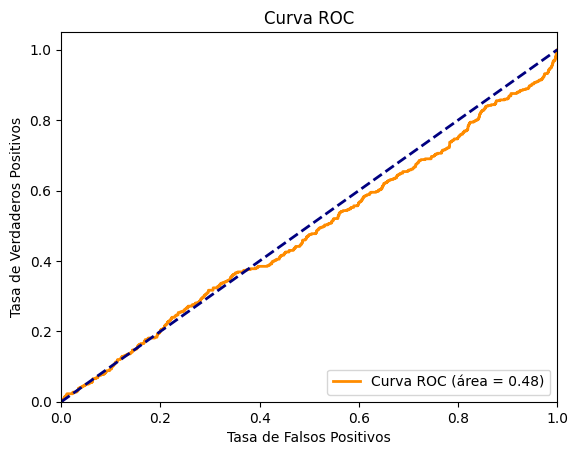

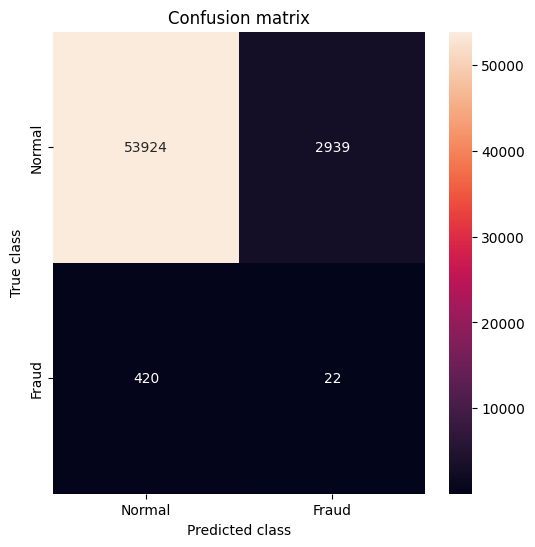


% de transacciones etiquetadas como fraude que fueron correctas (precisión): 22/(2939+22) = 0.74%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    22/(420+22) = 4.98%
% de transacciones normales que fueron identificadas correctamente (especificidad): 53924/(53924+2939) = 94.83%


In [30]:
# Evaluamos el rendimiento del modelo
evaluar_rendimiento_pca(pca)

#### Conclusión de la Evaluación de PCA

Los resultados obtenidos con PCA subrayan sus limitaciones en el contexto de detección de fraude. Mientras que PCA puede ser útil para reducir la dimensionalidad y visualizar datos, su capacidad para separar eficazmente las transacciones fraudulentas de las legítimas es insuficiente. Esto resalta la necesidad de explorar modelos más avanzados, como autoencoders y autoencoders variacionales, que pueden aprender representaciones más complejas de los datos y, potencialmente, mejorar significativamente la detección de anomalías.

La baja sensibilidad y precisión de PCA en nuestra evaluación sirven como un recordatorio crítico de que, mientras buscamos minimizar los falsos positivos (mejorando la precisión), no debemos hacerlo a expensas de pasar por alto casos reales de fraude (mejorando la sensibilidad). En consecuencia, nuestro enfoque se dirigirá hacia modelos que prometen un equilibrio más efectivo entre estos aspectos, buscando optimizar tanto la precisión como la sensibilidad para una detección de fraude más confiable y efectiva.

### 2. Modelo Autoencoder

##### Arquitectura
- El modelo sigue una arquitectura secuencial, dividida en dos partes principales: la fase de codificación (Encode) y la fase de decodificación (Decode).

**Fase de Codificación (Encode):**

1. **Capa Densa Inicial**: Recibe los datos de entrada (`input_dim`) y utiliza activación ELU (Exponential Linear Unit) para mantener la no-linealidad.

2. **Normalización por Batch**: Ayuda a acelerar el entrenamiento y reduce el overfitting mediante la normalización de las activaciones de la capa anterior.

3. **Dropout (0.1)**: Aplica un dropout del 10% para reducir el overfitting al "apagar" aleatoriamente algunas neuronas durante el entrenamiento.

4. **Capas Densas Intermedias**: Tres capas densas con 32, 16, y 8 unidades respectivamente, todas utilizando activación ELU para mantener no-linealidades complejas.

5. **Regularización L1 en Capa Densa**: La última capa de la sección de codificación tiene 4 unidades, activación ELU, y utiliza regularización L1 para fomentar la generalización.

**Fase de Decodificación (Decode):**

1. **Capas Densas de Decodificación**: Se inicia con una capa densa de 8 unidades, seguida de capas de 16 y 32 unidades, todas utilizando activación ELU para reconstruir los datos desde la representación codificada.

2. **Normalización por Batch y Dropout**: Similar a la fase de codificación, se aplica una capa de normalización por batch y una capa de dropout del 10% después de las capas densas para mejorar la estabilidad del entrenamiento y reducir el overfitting.

3. **Capa Densa Final**: La última capa densa tiene un número de unidades igual a `input_dim` y utiliza activación `sigmoid`. Esta capa reconstruye los datos de entrada a partir de las características codificadas, intentando minimizar la diferencia entre los datos originales y sus reconstrucciones.


**Optimizador:**

1. **Tipo de Optimizador: Adam**: Adam se elige por su capacidad para adaptar la tasa de aprendizaje de manera individual para cada parámetro, optimizando el entrenamiento en paisajes de error complejos.

2. **Tasa de Aprendizaje: 0.000005**:   Elegir una tasa de aprendizaje baja se prefiere para garantizar una convergencia suave y evitar el sobreajuste, facilitando así una mejor generalización del modelo a datos no vistos.



In [41]:
autoencoder = load_model('modelos-minmax/model_complete_v3_v34.h5',
                         compile=False)

autoencoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,652 (18.17 KB)

 Trainable params: 4,496 (17.56 KB)

 Non-trainable params: 156 (624.00 B)

#### Entrenamiento

- **Número de Épocas:** Se realizaron hasta 1000 iteraciones de entrenamiento, permitiendo un ajuste profundo del modelo a los datos. La cantidad significativa de épocas asegura que el modelo tenga suficiente tiempo para aprender las complejidades de los datos de transacciones.

- **Tamaño del Batch:** Se estableció en 128, un tamaño de lote que equilibra la eficiencia computacional y la estabilidad del aprendizaje. Un batch size adecuado permite una actualización de pesos más estable y un entrenamiento más rápido.

- **Callback - Early Stopping:** Implementado para prevenir el sobreajuste y mejorar la generalización. El entrenamiento se detiene automáticamente si el val_loss no mejora después de un número definido de épocas (patience). Además, restaura los mejores pesos encontrados durante el entrenamiento, asegurando que el modelo mantenga el mejor rendimiento posible en los datos de validación.

- **Objetivo del Entrenamiento:** El enfoque principal es minimizar el error de reconstrucción, medido a través del mse (error cuadrático medio) entre los datos de entrada y sus reconstrucciones. Este objetivo alinea el proceso de aprendizaje del autoencoder con la detección eficaz de anomalías, ya que las transacciones fraudulentas deberían tener un mayor error de reconstrucción.



#### Curvas de Entrenamiento

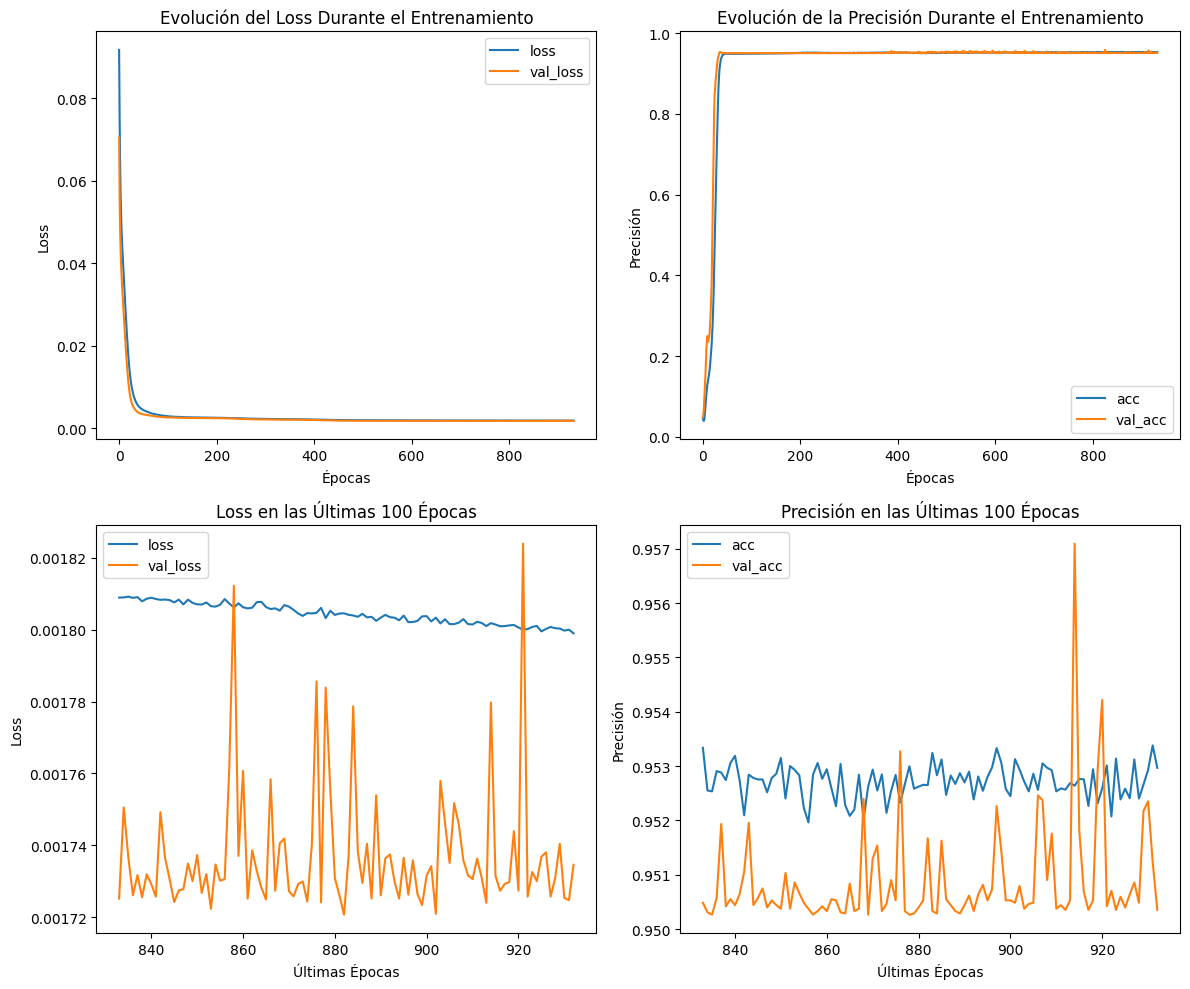

In [ ]:
# Cargamos el historial de entrenamiento
hist_path = '../modelos-minmax/v3_34_hist.npy'
hist_data = np.load(hist_path, allow_pickle=True).item()

plot_training_history_saves(hist_data)

#### Evaluación del Autoencoder en el Conjunto de Validación

Al aplicar nuestro modelo de Autoencoder al conjunto de validación, he obtenido resultados significativos que destacan la capacidad del modelo para identificar y diferenciar entre transacciones normales y fraudulentas. A continuación, se presentan los detalles clave de esta evaluación:

- **Umbral para la Detención de Outliers:** Se estableció en `0.00364`. Este valor se utilizó como límite para clasificar una transacción como normal o fraudulenta basándonos en el error de reconstrucción MSE obtenido.

- **Error de Reconstrucción MSE Medio:** En el conjunto de validación, el error medio fue de `0.0017`. Este bajo error medio indica que el modelo es capaz de reconstruir con precisión la mayoría de las transacciones normales, mientras que las transacciones fraudulentas presentan un error mayor, facilitando su identificación.

- **Área bajo la Curva ROC (AUC):** El modelo alcanzó una área bajo la curva ROC de `0.96`, demostrando una excelente capacidad para distinguir entre clases. Un valor cercano a 1 indica un rendimiento de clasificación superior.

- **Resultados de Clasificación:**

    - **Precisión:** Del total de transacciones clasificadas como fraudulentas, el `1.97%` fueron identificaciones correctas. Aunque puede parecer bajo, es importante considerar el contexto sobre la detección de fraude.
    
    - **Sensibilidad (Recall):** La capacidad del modelo para detectar transacciones fraudulentas fue del `92.00%`, lo que indica que casi todas las transacciones fraudulentas fueron correctamente identificadas como tales.

    - **Especificidad:** La precisión en la identificación de transacciones normales fue del `94.97%`, demostrando la habilidad del modelo para reconocer la mayoría de las transacciones legítimas sin clasificarlas erróneamente como fraudulentas.

   1/5687 [..............................] - ETA: 44:36

5687/5687 [==============================] - 9s 2ms/step
Umbral para la detección de outliers: 0.003639088466419562 

1424/1424 [==============================] - 2s 1ms/step
Error de reconstrucción MSE medio en el conjunto de validación: 0.0017072789988582867



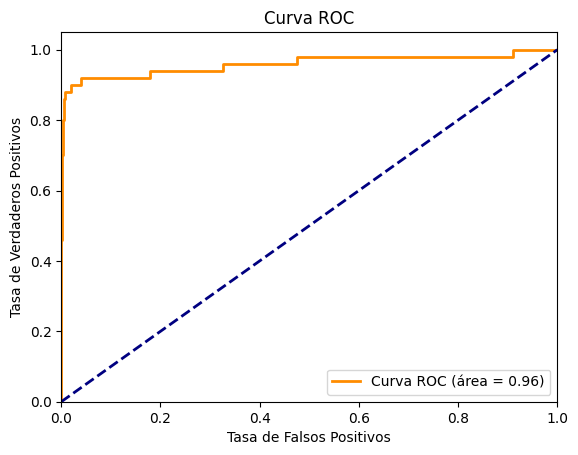

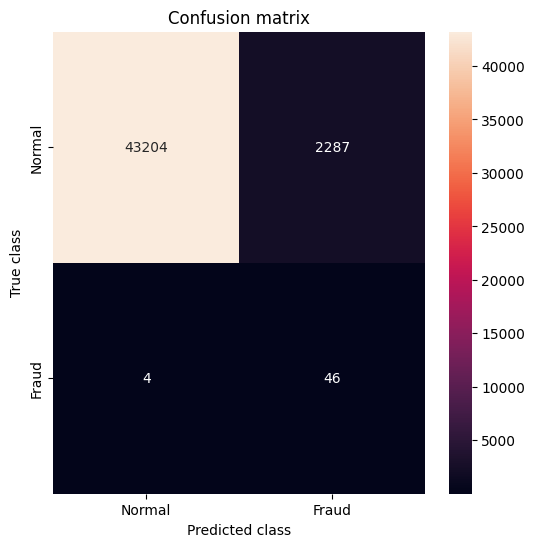


% de transacciones etiquetadas como fraude que fueron correctas (precisión): 46/(2287+46) = 1.97%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    46/(4+46) = 92.00%
% de transacciones normales que fueron identificadas correctamente (especificidad): 43204/(43204+2287) = 94.97%


In [ ]:
evaluar_rendimiento_autoencoder_saves(autoencoder)

#### Evaluación del Autoencoder en el Conjunto de Test

La evaluación de nuestro Autoencoder en el conjunto de test demuestra su eficacia en la identificación de transacciones fraudulentas, ofreciendo una visión detallada de su desempeño en un entorno de datos diverso y realista. A continuación, se presentan los puntos clave de esta evaluación:

- **Área bajo la Curva ROC (AUC)**: El modelo ha alcanzado un AUC de `0.95`, lo que indica una excelente capacidad para diferenciar entre transacciones fraudulentas y legítimas. Un AUC cercano a 1 sugiere que el modelo es altamente efectivo.

- **Resultados de Clasificación**:
  - **Precisión**: Un `11.77%` de las transacciones identificadas como fraudulentas fueron clasificaciones correctas. Este aumento en la precisión, comparado con los resultados en el conjunto de validación, sugiere que el modelo es aún más efectivo cuando se enfrenta a datos nuevos.

  - **Sensibilidad (Recall)**: La sensibilidad o capacidad del modelo para identificar correctamente las transacciones fraudulentas fue de `86.65%`. Esto indica que el modelo es capaz de capturar una gran mayoría de las actividades fraudulentas, minimizando los casos no detectados.
  
  - **Especificidad**: La especificidad del modelo, o su habilidad para identificar correctamente las transacciones legítimas, se mantuvo robusta en `94.95%`. Este valor asegura que la mayoría de las transacciones legítimas no son erróneamente marcadas como fraudulentas.

 239/5687 [>.............................] - ETA: 8s

5687/5687 [==============================] - 9s 2ms/step
Umbral para la detección de outliers: 0.003639088466419562 

1791/1791 [==============================] - 2s 1ms/step
Error de reconstrucción MSE medio en el conjunto de validación: 0.001903743042768987



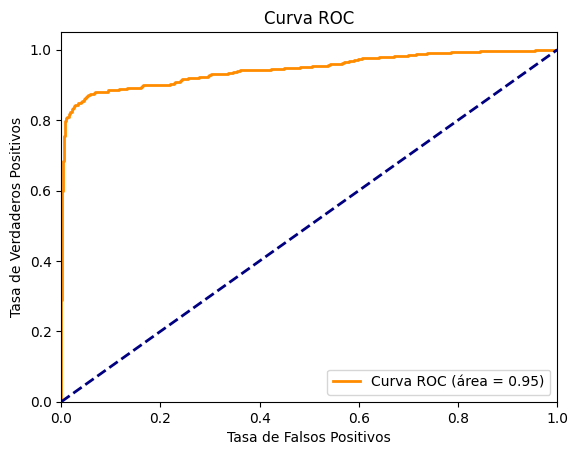

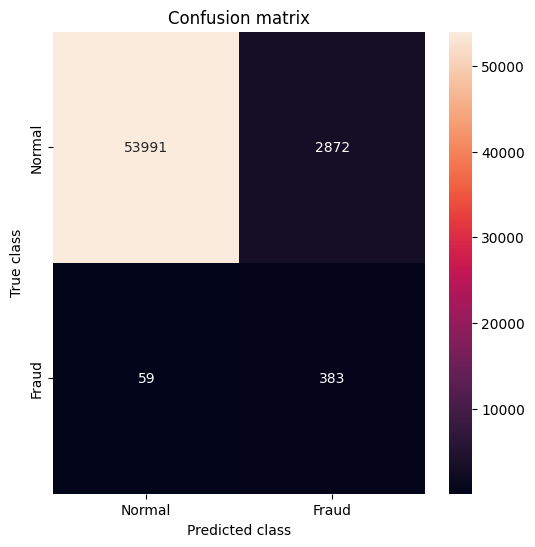


% de transacciones etiquetadas como fraude que fueron correctas (precisión): 383/(2872+383) = 11.77%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    383/(59+383) = 86.65%
% de transacciones normales que fueron identificadas correctamente (especificidad): 53991/(53991+2872) = 94.95%


In [ ]:
evaluar_rendimiento_autoencoder_saves_test(autoencoder)

### 3. Modelo Autoencoder Variacional

##### Arquitectura

El modelo VAE sigue una arquitectura más compleja y modular que el autoencoder simple. Veamos cada parte de la arquitectura:

1. **Codificador (Encoder)**:
   - La entrada del modelo es un tensor con forma `(None, 30)`, que representa los datos de entrada con 30 características.
   - La capa "encoder" es una parte funcional que produce tres salidas: `z_mean`, `z_log_var`, y `z`. Estas representan respectivamente la media, el logaritmo de la varianza y la distribución latente.
   - El codificador comprende una secuencia de capas densas intermedias con activación ELU.
   - Al final, se calculan `z_mean` y `z_log_var` mediante capas densas separadas.

2. **Decodificador (Decoder)**:
   - La parte del decodificador es una función funcional que toma la salida del codificador `z` y la decodifica en la salida final con la misma forma que los datos de entrada.
   - Consiste en capas densas intermedias con activación ELU, que finalmente se reconstruyen en la forma de salida original.

3. **Capas Densas y Regularización**:
   - Hay capas densas adicionales y capas de normalización por lotes en la entrada y salida del codificador y el decodificador para mejorar el rendimiento y la estabilidad del modelo.
   - Se aplica regularización mediante dropout después de ciertas capas densas para evitar el sobreajuste durante el entrenamiento.

4. **Función de Pérdida y Regularización**:
   - La pérdida del modelo VAE se compone de dos partes: la pérdida de reconstrucción y la divergencia KL (Kullback-Leibler) entre la distribución latente aprendida y la distribución latente prior.
   - La pérdida de reconstrucción se calcula como la diferencia cuadrada media entre los datos de entrada originales y los datos reconstruidos.
   - La divergencia KL mide qué tan bien la distribución latente aprendida se ajusta a una distribución latente prior deseada, generalmente una distribución normal.
   - Estas dos pérdidas se suman y se utilizan para entrenar el modelo VAE.


**Optimizador:**

1. **Tipo de Optimizador: Adam**: Adam se elige por su capacidad para adaptar la tasa de aprendizaje de manera individual para cada parámetro, optimizando el entrenamiento en paisajes de error complejos.

2. **Tasa de Aprendizaje: 0.00001**:   Elegir una tasa de aprendizaje baja se prefiere para garantizar una convergencia suave y evitar el sobreajuste, facilitando así una mejor generalización del modelo a datos no vistos.



In [ ]:
vae = load_model('vae_v5.h5')

vae.summary()


Model: "vae_mlp"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 30)]                 0         []                            
                                                                                                  
 encoder (Functional)        [(None, 2),                  5044      ['input_4[0][0]']             
                              (None, 2),                                                          
                              (None, 2)]                                                          
                                                                                                  
 decoder (Functional)        (None, 30)                   5102      ['encoder[0][2]']             
                                                                                            

#### Entrenamiento

- **Número de Épocas:** Se realizaron hasta 317 iteraciones de entrenamiento, permitiendo un ajuste profundo del modelo a los datos. La cantidad significativa de épocas asegura que el modelo tenga suficiente tiempo para aprender las complejidades de los datos de transacciones.

- **Tamaño del Batch:** Se estableció en 256, un tamaño de lote que equilibra la eficiencia computacional y la estabilidad del aprendizaje. Un batch size adecuado permite una actualización de pesos más estable y un entrenamiento más rápido.

- **Callback - Early Stopping:** Implementado para prevenir el sobreajuste y mejorar la generalización. El entrenamiento se detiene automáticamente si el val_loss no mejora después de un número definido de épocas (patience). Además, restaura los mejores pesos encontrados durante el entrenamiento, asegurando que el modelo mantenga el mejor rendimiento posible en los datos de validación.

- **Objetivo del Entrenamiento:** El enfoque principal es minimizar el error de reconstrucción, medido a través del mse (error cuadrático medio) entre los datos de entrada y sus reconstrucciones. Este objetivo alinea el proceso de aprendizaje del autoencoder con la detección eficaz de anomalías, ya que las transacciones fraudulentas deberían tener un mayor error de reconstrucción.



#### Curvas de Entrenamiento

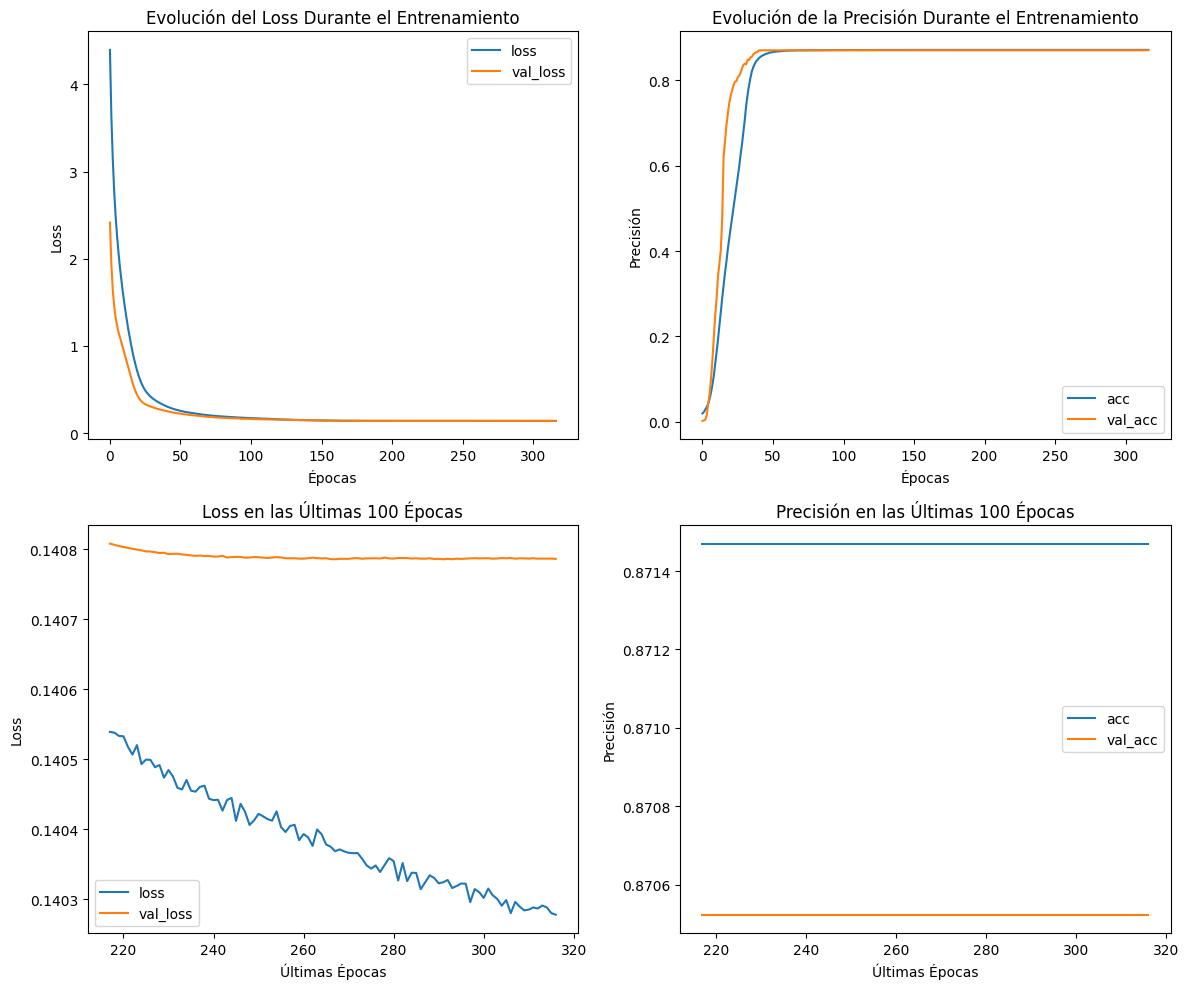

In [ ]:
# Cargamos el historial de entrenamiento
hist_path = 'vae_hist_v5.npy'
hist_data = np.load(hist_path, allow_pickle=True).item()

plot_training_history_saves(hist_data)

#### Evaluación de Autoencoder Variacional en el Conjunto de Validación

Al evaluar nuestro modelo de Autoencoder Variacional (VAE) en el conjunto de validación, he obtenido métricas importantes que indican su desempeño en la detección de transacciones fraudulentas. A continuación, se detallan los resultados clave de esta evaluación:

- **Umbral para la Detección de Outliers:** El umbral para la detección de outliers se estableció en `0.017`. Este valor se utiliza para distinguir entre transacciones normales y fraudulentas en función del error de reconstrucción MSE obtenido.

- **Error de Reconstrucción MSE Medio:** En el conjunto de validación, el error medio de reconstrucción fue de `0.0107`. Este valor indica la discrepancia entre los datos originales y sus reconstrucciones, lo que ayuda en la identificación de transacciones anómalas.

- **Área bajo la Curva ROC (AUC):** El modelo alcanzó un valor de ROC de `0.93`, lo que indica una capacidad sólida para discriminar entre transacciones normales y fraudulentas.

- **Resultados de Clasificación:**

    - **Precisión:** Del total de transacciones etiquetadas como fraudulentas, solo el `1.63%` fueron identificadas correctamente como tales. Esto sugiere que, aunque el modelo puede detectar algunas transacciones fraudulentas, también clasifica incorrectamente muchas transacciones normales como fraudulentas.
    
    - **Sensibilidad (Recall):** La sensibilidad del modelo, es decir, su capacidad para detectar transacciones fraudulentas, fue del `80.00%`. Esto indica que el modelo pudo identificar correctamente el `80.00%` de todas las transacciones fraudulentas presentes en el conjunto de datos.
    
    - **Especificidad:** La especificidad del modelo, que representa su habilidad para identificar transacciones normales correctamente, fue del `94.69%`. Esto indica que el modelo fue eficaz en reconocer la mayoría de las transacciones legítimas sin clasificarlas erróneamente como fraudulentas.


5687/5687 [==============================] - 11s 2ms/step
Umbral para la detección de outliers: 0.01704364512831514 

1424/1424 [==============================] - 3s 2ms/step
Error de reconstrucción MSE medio en el conjunto de validación: 0.010748038791467388



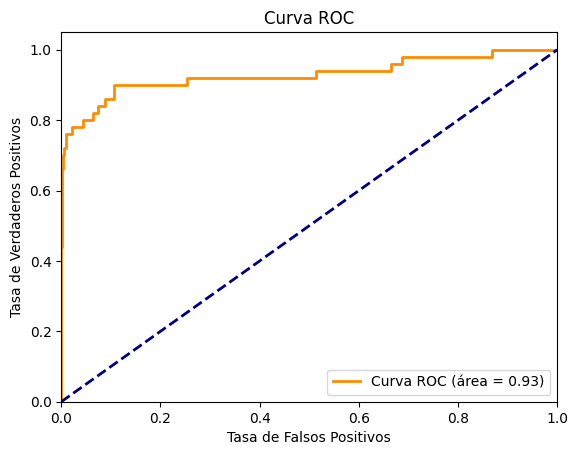

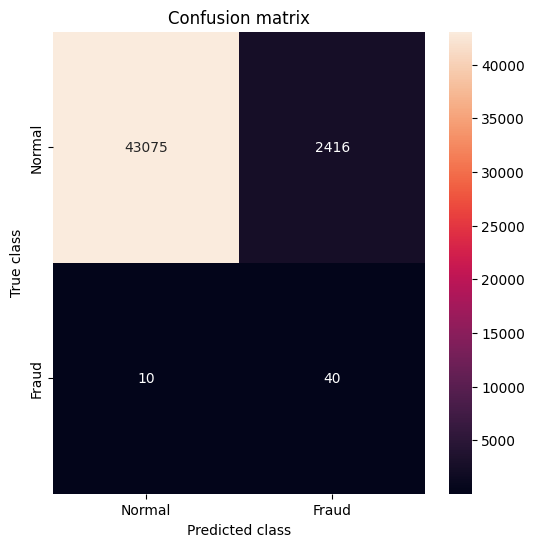


% de transacciones etiquetadas como fraude que fueron correctas (precisión): 40/(2416+40) = 1.63%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    40/(10+40) = 80.00%
% de transacciones normales que fueron identificadas correctamente (especificidad): 43075/(43075+2416) = 94.69%


In [ ]:
evaluar_rendimiento_autoencoder_saves(vae)

#### Evaluación del Autoencoder Variacional en el Conjunto de Test

La evaluación de nuestro modelo de Autoencoder Variacional en el conjunto de test proporciona información crucial sobre su rendimiento en un entorno de datos diverso y realista. A continuación, se detallan los resultados clave de esta evaluación:

- **Umbral para la Detección de Outliers:** El umbral para la detección de outliers se estableció en `0.017`. Este valor se utiliza para clasificar las transacciones como normales o fraudulentas basándose en el error de reconstrucción MSE obtenido.

- **Error de Reconstrucción MSE Medio:** En el conjunto de test, el error medio de reconstrucción fue de `0.0109`. Este valor indica la discrepancia entre los datos originales y sus reconstrucciones, lo que ayuda en la identificación de transacciones anómalas.

- **Área bajo la Curva ROC (AUC):** El modelo alcanzó un valor de ROC de `0.92`, lo que sugiere una buena capacidad para distinguir entre transacciones normales y fraudulentas.

- **Resultados de Clasificación:**
    - **Precisión:** De todas las transacciones etiquetadas como fraudulentas, solo el `10.06%` fueron identificadas correctamente como tales. Esto indica que el modelo tiende a clasificar incorrectamente muchas transacciones normales como fraudulentas.
    - **Sensibilidad (Recall):** La capacidad del modelo para detectar transacciones fraudulentas fue del `71.49%`. Esto indica que el modelo pudo identificar correctamente el `71.49%` de todas las transacciones fraudulentas presentes en el conjunto de datos.
    - **Especificidad:** La especificidad del modelo, que representa su habilidad para identificar transacciones normales correctamente, fue del `95.03%`. Esto indica que el modelo fue eficaz en reconocer la mayoría de las transacciones legítimas sin clasificarlas erróneamente como fraudulentas.

5687/5687 [==============================] - 10s 2ms/step
Umbral para la detección de outliers: 0.017043646598349546 

1791/1791 [==============================] - 3s 2ms/step
Error de reconstrucción MSE medio en el conjunto de validación: 0.010944392463967882



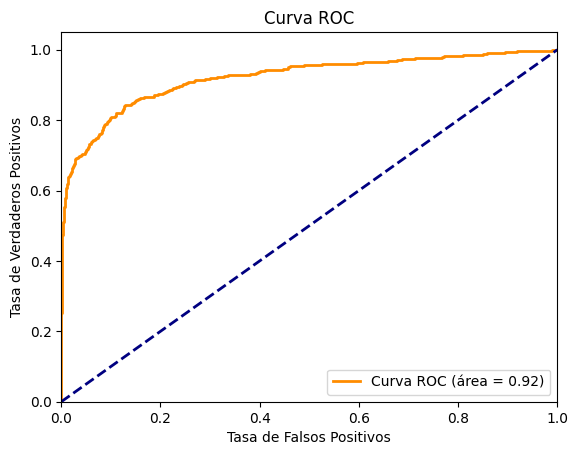

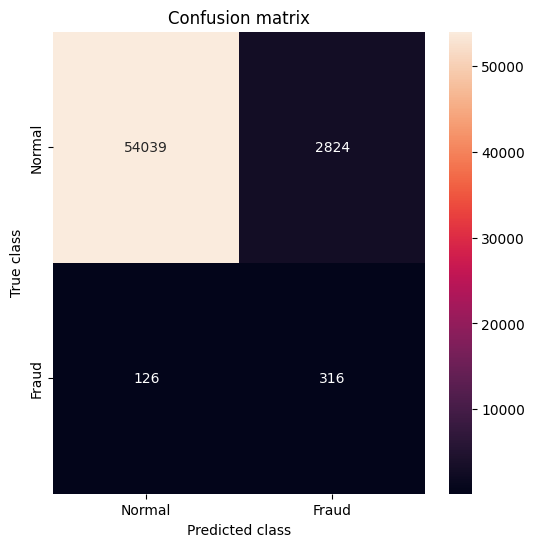


% de transacciones etiquetadas como fraude que fueron correctas (precisión): 316/(2824+316) = 10.06%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    316/(126+316) = 71.49%
% de transacciones normales que fueron identificadas correctamente (especificidad): 54039/(54039+2824) = 95.03%


In [ ]:
evaluar_rendimiento_autoencoder_saves_test(vae)

## Resultados Con Balanceo de Datos

### 1. PCA: Punto de Referencia Inicial

#### Implementación de PCA

Para comenzar nuestra comparativa, inicializamos PCA con 30 componentes, lo que nos permite observar cómo se comporta este modelo en el contexto de nuestros datos de entrenamiento:

In [33]:
# Inicializamos PCA con 30 componentes
pca = PCA(n_components=30)

# Ajustamos PCA con los datos de entrenamiento
pca.fit(X_train_v2)

PCA(n_components=30)

#### Evaluación de Rendimiento de PCA

Tras implementar PCA y evaluar su rendimiento en la detección de anomalías, observamos los siguientes resultados:

- **Curva ROC**: Un valor de `0.51` indica un rendimiento cercano a la aleatoriedad. Lo que buscamos son valores más cercanos a 1, lo que indica una mayor capacidad de discriminación entre clases.

- **Precisión**: La precisión extremadamente baja del `0.72%` indica que, de las transacciones identificadas como fraudulentas, solo un pequeño porcentaje fue clasificado correctamente. Este resultado sugiere una alta tasa de falsos positivos.

- **Sensibilidad (Recall)**: Una sensibilidad del `4.75%` significa que solo es capaz de identificar una cantidad muy pequeña de lass transacciones fraudulentas reales.

- **Especificidad**: Aunque la especificidad es relativamente alta `94.88%`, mostrando que identifica la gran parte de las transacciones correctas, este resultado no compensa la baja capacidad del modelo para identificar fraudes.



Error de reconstrucción MSE medio en el conjunto de validación: 2.4454140815783535e-30



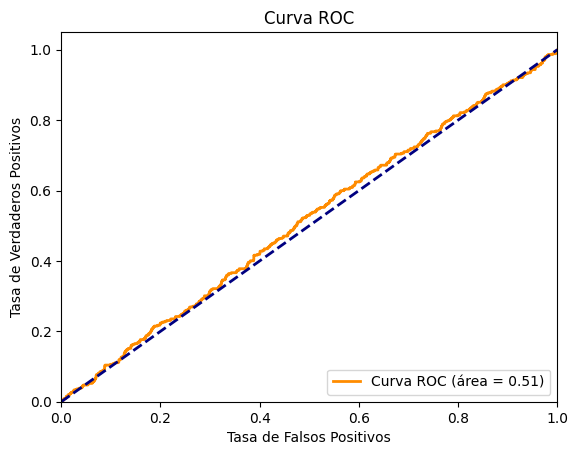

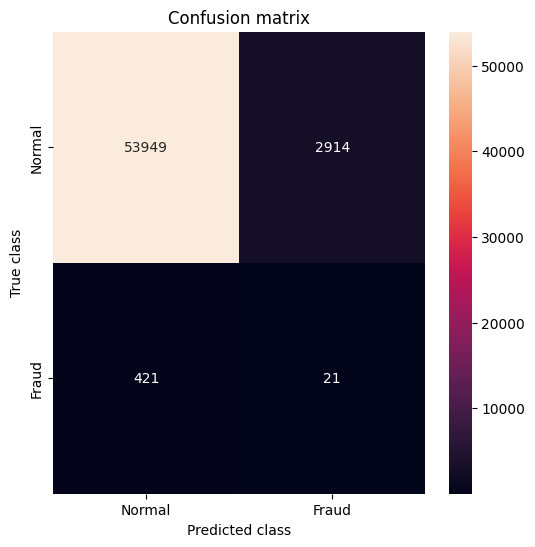


% de transacciones etiquetadas como fraude que fueron correctas (precisión): 21/(2914+21) = 0.72%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    21/(421+21) = 4.75%
% de transacciones normales que fueron identificadas correctamente (especificidad): 53949/(53949+2914) = 94.88%


In [34]:
# Evaluamos el rendimiento del modelo
evaluar_rendimiento_pca(pca)

### 2. Modelo Autoencoder

##### Arquitectura
- El modelo sigue una arquitectura **secuencial** con dos bloques principales: **Codificador (Encoder)** y **Decodificador (Decoder)**, conectados por una **capa de cuello de botella** con regularización.

**Fase de Codificación (Encode):**

1. **Capa Densa de Entrada**: `Dense(input_dim, activation='elu')` recibe vectores de dimensión `input_dim`. La activación **ELU** mantiene la no linealidad y mejora la estabilidad frente a valores negativos.

2. **Batch Normalization**: normaliza activaciones para acelerar el entrenamiento y disminuir el covariate shift.

3. **Dropout (0.1)**: apaga aleatoriamente el 10% de neuronas para mitigar overfitting.

4. **Capas Densas Intermedias**: `Dense(64) → Dense(32) → Dense(16)` con **ELU** en todas; incrementan la capacidad del modelo para aprender patrones no lineales complejos.

5. **BatchNorm + Dropout**: nuevo bloque de estabilización y regularización tras las capas intermedias.

6. **Capa Densa (8 unidades)**: compacta aún más la representación previa al cuello de botella.

**Fase de Decodificación (Decode):**

1. **Capas Densas de Reconstrucción**: `Dense(8) → Dense(16) → Dense(32) → Dense(64)` con **ELU**; expanden gradualmente la representación latente hacia el espacio original.

2. **Batch Normalization + Dropout (0.1)**: estabilizan el aprendizaje y reducen el riesgo de sobreajuste en la parte final de la reconstrucción.


**Optimizador**

1. **Adam**: elegido por su adaptación de tasa de aprendizaje por parámetro y buen desempeño en espacios de pérdida no convexos.

2. **Learning rate = 5e-6**: valor bajo para una **convergencia suave** y estable en alta dimensionalidad.




In [43]:
autoencoder_v2 = load_model(
    'modelos-minmax/model_complete_v3_v38.h5',
    compile=False
)

autoencoder_v2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,924 (42.67 KB)

 Trainable params: 10,704 (41.81 KB)

 Non-trainable params: 220 (880.00 B)

#### Entrenamiento

- **Número de Épocas:** Se realizaron hasta 2500 iteraciones de entrenamiento, permitiendo un ajuste profundo del modelo a los datos. La cantidad significativa de épocas asegura que el modelo tenga suficiente tiempo para aprender las complejidades de los datos de transacciones.

- **Tamaño del Batch:** Se estableció en 128, un tamaño de lote que equilibra la eficiencia computacional y la estabilidad del aprendizaje. Un batch size adecuado permite una actualización de pesos más estable y un entrenamiento más rápido.

- **Callback - Early Stopping:** Implementado para prevenir el sobreajuste y mejorar la generalización. El entrenamiento se detiene automáticamente si el val_loss no mejora después de un número definido de épocas (patience). Además, restaura los mejores pesos encontrados durante el entrenamiento, asegurando que el modelo mantenga el mejor rendimiento posible en los datos de validación.

- **Objetivo del Entrenamiento:** El enfoque principal es minimizar el error de reconstrucción, medido a través del mse (error cuadrático medio) entre los datos de entrada y sus reconstrucciones. Este objetivo alinea el proceso de aprendizaje del autoencoder con la detección eficaz de anomalías, ya que las transacciones fraudulentas deberían tener un mayor error de reconstrucción.



#### Curvas de Entrenamiento

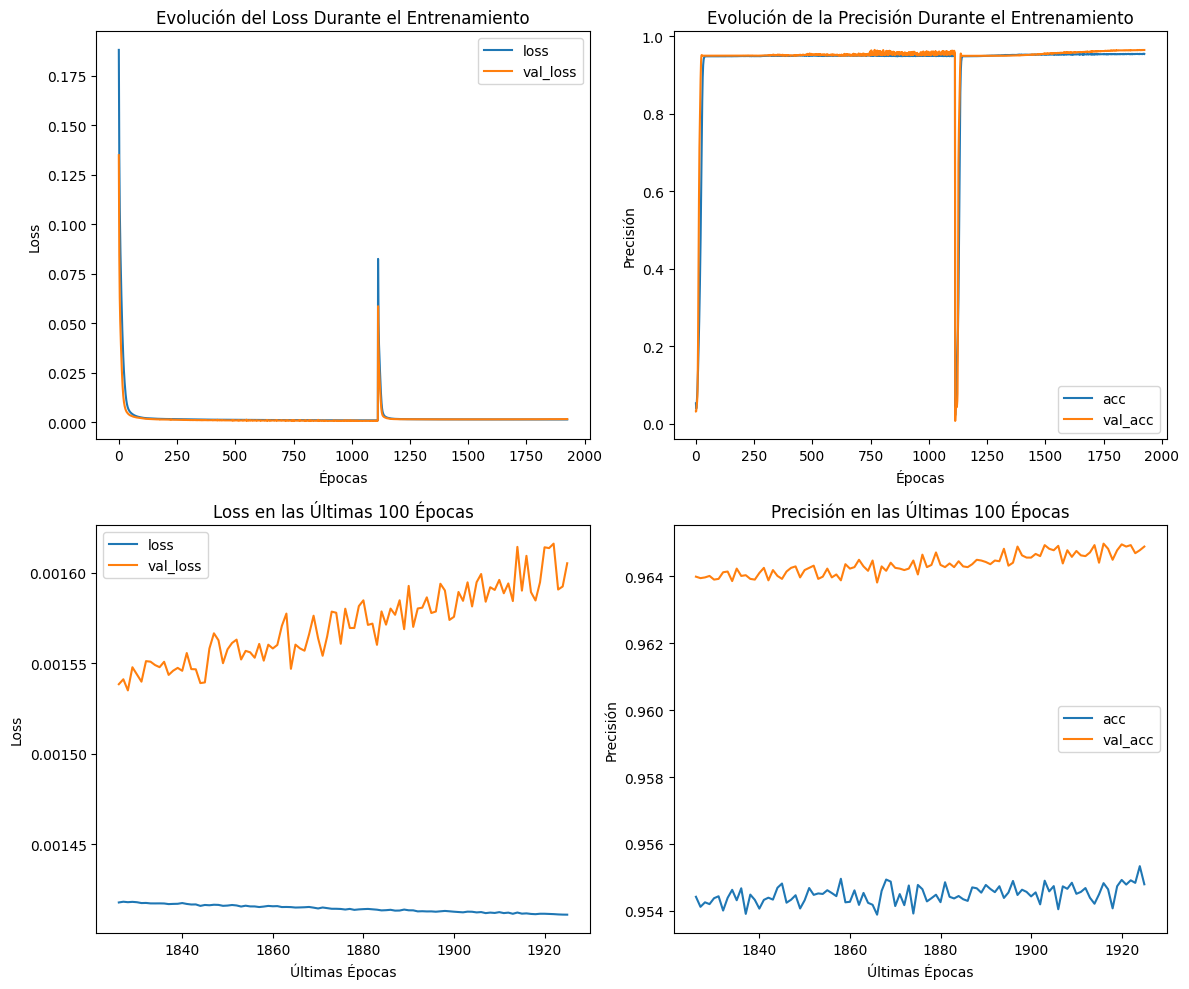

In [51]:
# Cargamos el historial de entrenamiento
hist_path = 'modelos-minmax/v3_36_hist.npy'
hist_data = np.load(hist_path, allow_pickle=True).item()

plot_training_history_saves(hist_data)

#### Evaluación del Autoencoder en el Conjunto de Validación


Al aplicar nuestro modelo de Autoencoder al conjunto de validación, he obtenido resultados que evidencian su capacidad para distinguir entre transacciones normales y fraudulentas. A continuación, se presentan los detalles clave de esta evaluación:

- **Umbral para la Detección de Outliers:** `0.007`.  
  Este valor se utilizó como límite de decisión para clasificar una transacción como normal o fraudulenta en función del **error de reconstrucción MSE**.

- **Error de Reconstrucción MSE Medio:** `0.005`.  
  Un error medio inferior al umbral sugiere que el modelo **reconstruye adecuadamente** la mayoría de transacciones normales, mientras que las **fraudulentas** tienden a presentar errores más altos, facilitando su identificación.

- **Área bajo la Curva ROC (AUC):** *no calculada en esta evaluación*.  
  En este análisis se empleó un **umbral fijo**. Se recomienda complementar con **ROC** y, dado el desbalance, con **Precision–Recall (AUPRC)** para una valoración más completa del rendimiento.

- **Resultados de Clasificación:** 

  - **Precisión (PPV):** `2.32%` — del total de transacciones clasificadas como fraudulentas, esta proporción fueron **fraudes reales**. 

  - **Sensibilidad (Recall):** `83.54%` — el modelo **detectó** la mayoría de las transacciones fraudulentas presentes en validación.  

  - **Especificidad:** `93.90%` — el modelo **reconoció** correctamente la gran mayoría de transacciones normales.


8124/8124 ━━━━━━━━━━━━━━━━━━━━ 5s 611us/step
Umbral para la detección de outliers: 0.007021578016412935 

1425/1425 ━━━━━━━━━━━━━━━━━━━━ 1s 596us/step
Error de reconstrucción MSE medio en el conjunto de validación: 0.005416080474197231



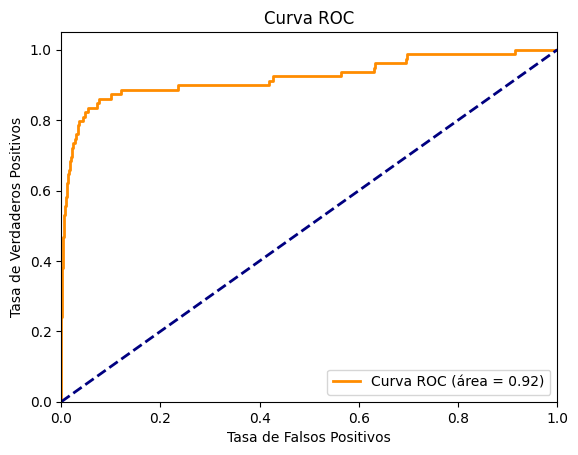

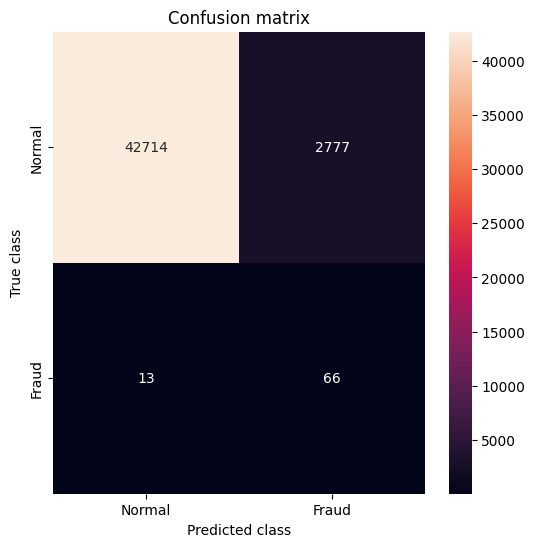

Las clasificaciones usando el umbral para la detección de outliers son las siguientes:

[[42714  2777]
 [   13    66]]

% de transacciones etiquetadas como fraude que fueron correctas (precisión): 66/(2777+66) = 2.32%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    66/(13+66) = 83.54%
% de transacciones normales que fueron identificadas correctamente (especificidad): 42714/(42714+2777) = 93.90%


In [77]:
evaluar_rendimiento_autoencoder_saves_v2(autoencoder_v2)

#### Evaluación del Autoencoder en el Conjunto de Test

La evaluación del Autoencoder sobre el conjunto de **test** permite medir su comportamiento en un escenario realista con datos no vistos. A continuación se detallan los resultados clave:

- **Umbral para la Detección de Outliers:** `0.007`.  
  Se etiqueta como **fraude** toda transacción cuyo MSE de reconstrucción sea **≥** este umbral.

- **Error de Reconstrucción MSE Medio (test):** `0.005`.  
  Un valor medio por debajo del umbral sugiere una **buena reconstrucción** de la mayoría de transacciones normales, mientras que las transacciones fraudulentas tienden a **superarlo**.

- **Área bajo la Curva ROC (AUC):** `0.94`.  
  La curva ROC (ver figura) refleja una **alta capacidad discriminativa** del modelo entre clases.

- **Resultados de Clasificación:**

  - **Precisión (PPV):** `2.3%` — del total de alertas de fraude, esta proporción fueron **fraudes reales**.

  - **Sensibilidad (Recall):** `82.83%` — el modelo **detecta** la mayoría de fraudes presentes en test.

  - **Especificidad:** `93.86%` — el modelo **reconoce** correctamente la gran mayoría de transacciones legítimas.


8124/8124 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
Umbral para la detección de outliers: 0.007021578016412935 

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Error de reconstrucción MSE medio en el conjunto de validación: 0.005419422070870862



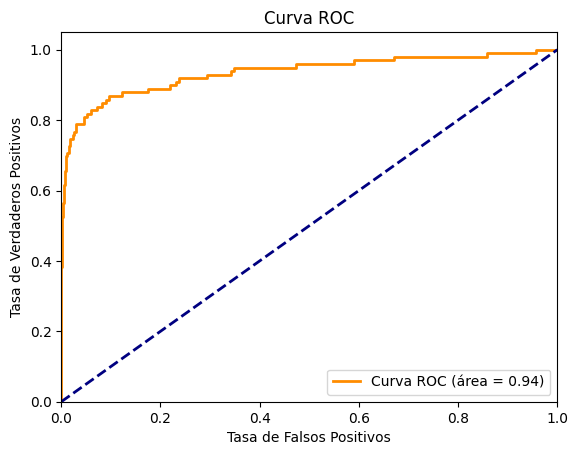

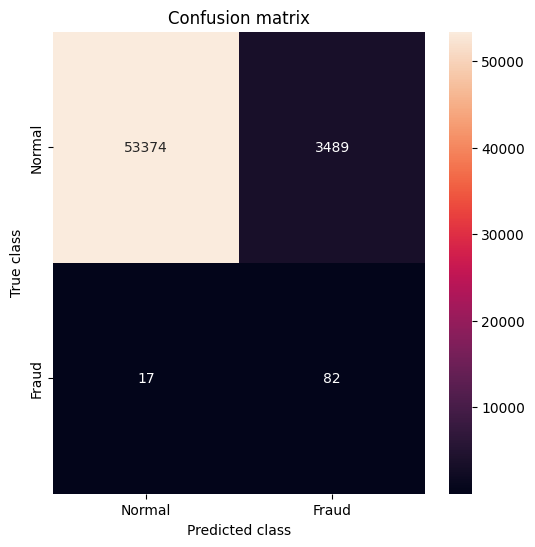


% de transacciones etiquetadas como fraude que fueron correctas (precisión): 82/(3489+82) = 2.30%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    82/(17+82) = 82.83%
% de transacciones normales que fueron identificadas correctamente (especificidad): 53374/(53374+3489) = 93.86%


In [45]:
evaluar_rendimiento_autoencoder_saves_test_v2(autoencoder_v2)

### 3. Modelo Autoencoder Variacional

##### Arquitectura

El modelo VAE presenta una arquitectura funcional con **codificador**, **cuello de botella probabilístico** y **decodificador**, incorporando normalización, *dropout* y regularización L1.

1. **Codificador (Encoder)**

   - **Entrada:** tensor de forma `(None, input_dim)`, con `input_dim` características.
   - **Bloque inicial:** `Dense(units=input_dim, activation='elu', kernel_regularizer=l1(0.001))`  
     + **BatchNormalization** → estabiliza distribuciones internas.  
     + **Dropout (0.1)** → reduce sobreajuste.
   - **Profundización:** `Dense(64, activation='elu')` → **BN** → `Dense(32, activation='elu')` → **BN**.  
     Se emplea **ELU** en el encoder para mejorar la representación de valores negativos y acelerar la convergencia.

2. **Cuello de Botella (Espacio Latente)**

   - **Dimensión latente:** `latent_dim = 4`.
   - **Parámetros de la distribución:**  
     - `z_mean = Dense(4)` (media).  
     - `z_log_var = Dense(4)` (log-varianza).  
   - **Muestreo (trick de reparametrización):** `z = Lambda(sampling)([z_mean, z_log_var])`, donde  
     `z = z_mean + exp(0.5 * z_log_var) * ε`, con `ε ~ N(0, I)`.  
     Esto permite **retropropagación** a través del muestreo estocástico.

3. **Decodificador (Decoder)**

   - **Entrada latente:** `(None, 4)`.
   - **Reconstrucción progresiva:** `Dense(32, activation='relu')` → **BN** → `Dense(64, activation='relu')` → **BN**.  
     Se utiliza **ReLU** en el decodificador para favorecer activaciones dispersas y estables.
   - **Salida:** `Dense(input_dim, activation='sigmoid')`.  
     > **Nota:** `sigmoid` asume variables **escaladas a [0, 1]** (p. ej., `MinMaxScaler`). Si no, usar `linear` o reescalar.

4. **Pérdida del VAE y Regularización**

   - Se incorpora una capa personalizada **`VAELossLayer`** que recibe: **entradas reales**, **reconstrucciones**, **`z_mean`** y **`z_log_var`**.  
   - La pérdida total es la suma de:  
     - **Pérdida de reconstrucción** (aquí basada en **MSE** entre entrada y salida).  
     - **Divergencia KL**: penaliza la desviación de `q(z|x)` respecto al prior `N(0, I)`, regularizando el espacio latente.
   - Esta capa **inyecta la pérdida compuesta** en el grafo del modelo; el `loss="mse"` del `compile` actúa como marcador pero la pérdida efectiva proviene de `VAELossLayer`.

**Optimizador**

1. **Adam**: adecuado para paisajes no convexos y gradientes ruidosos.

2. **Tasa de aprendizaje:** `1e-5` (baja), favoreciendo **convergencia suave** y menor riesgo de sobreajuste.



In [ ]:
vae_v2 = tf.keras.models.load_model(
    'modelos-minmax/model_complete_v2_7.h5',
    custom_objects={
        'sampling': sampling,
        'VAELossLayer': VAELossLayer
    }, compile=False
)

vae_v2.summary()


Model: "new_vae_model_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 30)        │        930 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30)        │        120 │ dense_26[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 64)        │      1,984 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_27[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_28[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 4)         │        132 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 4)         │        132 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 4)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 30)        │      4,606 │ z[0][0]           │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss            │ (None, 30)        │          0 │ encoder_input[0]… │
│ (VAELossLayer)      │                   │            │ decoder[0][0],    │
│                     │                   │            │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,368 (40.50 KB)

 Trainable params: 9,924 (38.77 KB)

 Non-trainable params: 444 (1.73 KB)

#### Entrenamiento

- **Número de Épocas:** Se realizaron hasta 780 iteraciones de entrenamiento, permitiendo un ajuste profundo del modelo a los datos. La cantidad significativa de épocas asegura que el modelo tenga suficiente tiempo para aprender las complejidades de los datos de transacciones.

- **Tamaño del Batch:** Se estableció en 256, un tamaño de lote que equilibra la eficiencia computacional y la estabilidad del aprendizaje. Un batch size adecuado permite una actualización de pesos más estable y un entrenamiento más rápido.

- **Callback - Early Stopping:** Implementado para prevenir el sobreajuste y mejorar la generalización. El entrenamiento se detiene automáticamente si el val_loss no mejora después de un número definido de épocas (patience). Además, restaura los mejores pesos encontrados durante el entrenamiento, asegurando que el modelo mantenga el mejor rendimiento posible en los datos de validación.

- **Objetivo del Entrenamiento:** El enfoque principal es minimizar el error de reconstrucción, medido a través del mse (error cuadrático medio) entre los datos de entrada y sus reconstrucciones. Este objetivo alinea el proceso de aprendizaje del autoencoder con la detección eficaz de anomalías, ya que las transacciones fraudulentas deberían tener un mayor error de reconstrucción.



#### Curvas de Entrenamiento

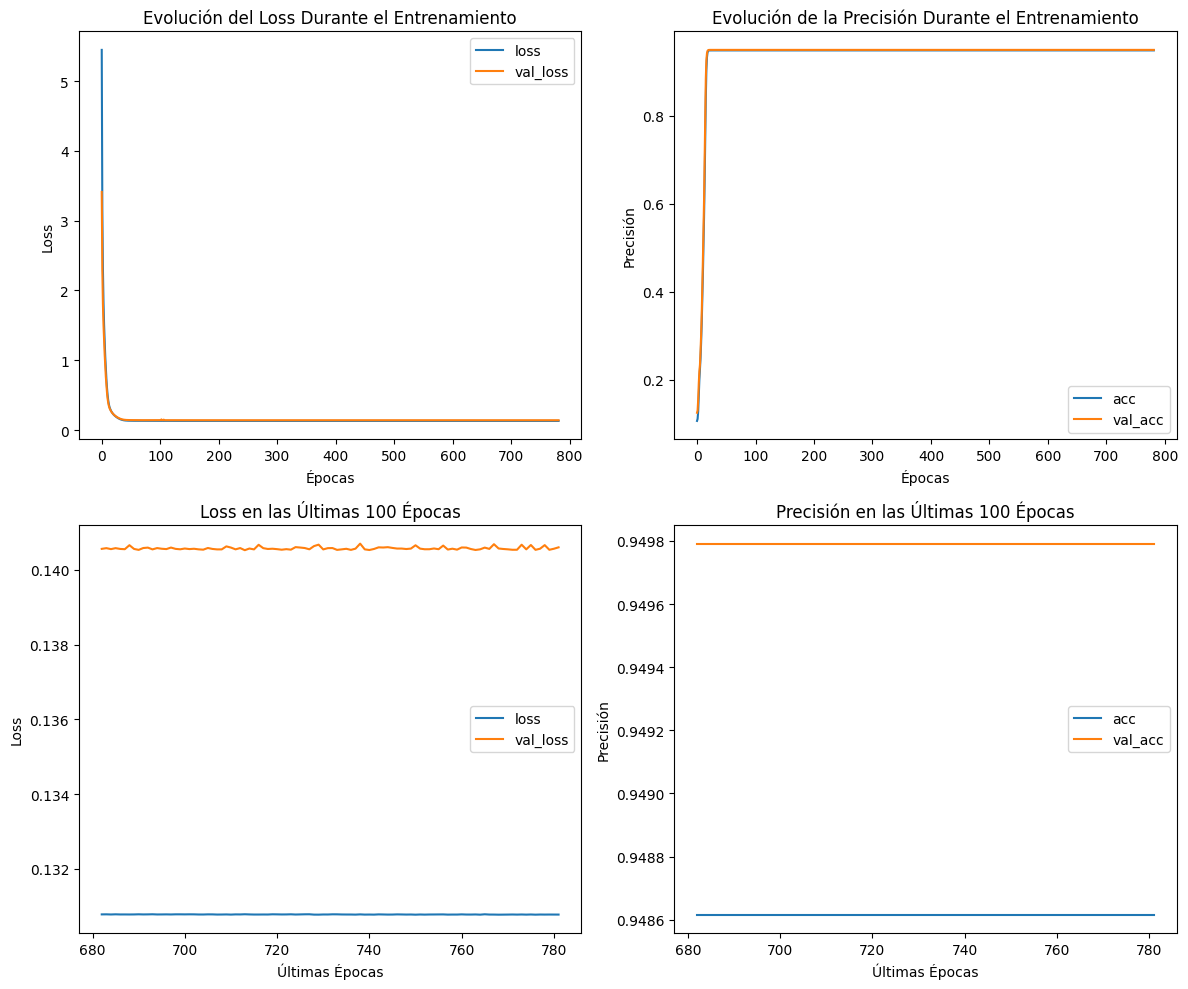

In [42]:
# Cargamos el historial de entrenamiento
hist_path = 'modelos-minmax/v2_7_hist.npy'
hist_data = np.load(hist_path, allow_pickle=True).item()

plot_training_history_saves(hist_data)

#### Evaluación de Autoencoder Variacional en el Conjunto de Validación

Al evaluar nuestro modelo de Autoencoder Variacional (VAE) en el conjunto de validación, he obtenido métricas que describen su capacidad para detectar transacciones fraudulentas. A continuación, se detallan los resultados clave:

- **Umbral para la Detección de Outliers:** `0.024`.  
  Este valor se utilizó para distinguir entre transacciones normales y fraudulentas en función del **error de reconstrucción (MSE)**.

- **Error de Reconstrucción MSE Medio:** `0.0159`.  
  Un error medio inferior al umbral sugiere que el modelo reconstruye adecuadamente la mayoría de las transacciones normales, mientras que las fraudulentas tienden a presentar errores más altos.

- **Área bajo la Curva ROC (AUC):** `0.91`.  
  Este valor, observado en la curva ROC (ver figura), indica una **capacidad discriminativa sólida** del modelo para separar clases.

- **Resultados de Clasificación:**
  - **Precisión (PPV):** `1.79%` — del total de transacciones etiquetadas como fraude, esta proporción fueron **fraudes reales**.
  - **Sensibilidad (Recall):** `58.23%` — el modelo **detectó** cerca de la mitad de las transacciones fraudulentas presentes en validación.
  - **Especificidad:** `94.45%` — el modelo **reconoció** correctamente la gran mayoría de transacciones legítimas.



8124/8124 ━━━━━━━━━━━━━━━━━━━━ 5s 591us/step
Umbral para la detección de outliers: 0.024016640489031373 

1425/1425 ━━━━━━━━━━━━━━━━━━━━ 1s 603us/step
Error de reconstrucción MSE medio en el conjunto de validación: 0.015962846456961406



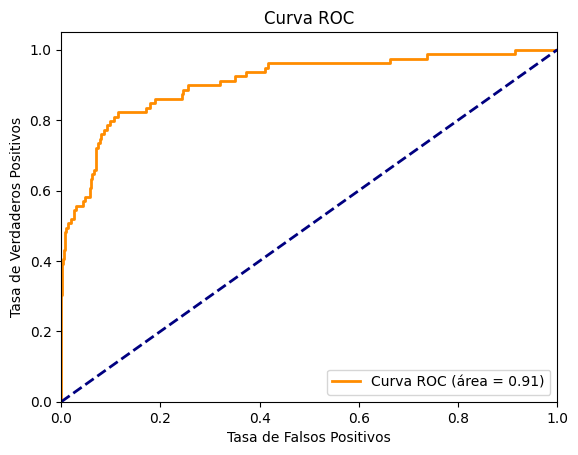

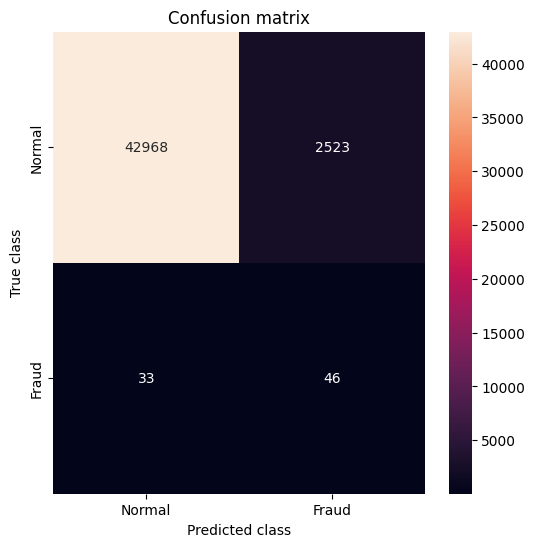

Las clasificaciones usando el umbral para la detección de outliers son las siguientes:

[[42968  2523]
 [   33    46]]

% de transacciones etiquetadas como fraude que fueron correctas (precisión): 46/(2523+46) = 1.79%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    46/(33+46) = 58.23%
% de transacciones normales que fueron identificadas correctamente (especificidad): 42968/(42968+2523) = 94.45%


In [130]:
evaluar_rendimiento_autoencoder_saves_v2(vae_v2)

#### Evaluación del Autoencoder Variacional en el Conjunto de Test

La evaluación del VAE sobre el **conjunto de test** ofrece una visión clara de su rendimiento en datos no vistos. Los resultados clave son:

- **Umbral para la Detección de Outliers:** `0.0138`.  
  Se clasifica como **fraude** toda transacción cuyo MSE de reconstrucción sea **≥** este umbral.

- **Error de Reconstrucción MSE Medio (test):** `0.005`.  
  Un valor medio por debajo del umbral sugiere una **reconstrucción adecuada** de la mayoría de transacciones normales.

- **Área bajo la Curva ROC (AUC):** `0.93`.  
  La curva ROC (ver figura) indica **buena capacidad discriminativa** del modelo.

- **Resultados de Clasificación:**
  - **Precisión (PPV):** `1.98%` — del total de alertas de fraude, esta proporción fueron **fraudes reales**.
  - **Sensibilidad (Recall):** `71.72%` — el modelo **detecta** un poco más de las transacciones fraudulentas.
  - **Especificidad:** `93.783%` — el modelo **reconoce** correctamente la gran mayoría de transacciones legítimas.


8124/8124 ━━━━━━━━━━━━━━━━━━━━ 5s 614us/step
Umbral para la detección de outliers: 0.013870126075097348 

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 601us/step
Error de reconstrucción MSE medio en el conjunto de validación: 0.005800921143514096



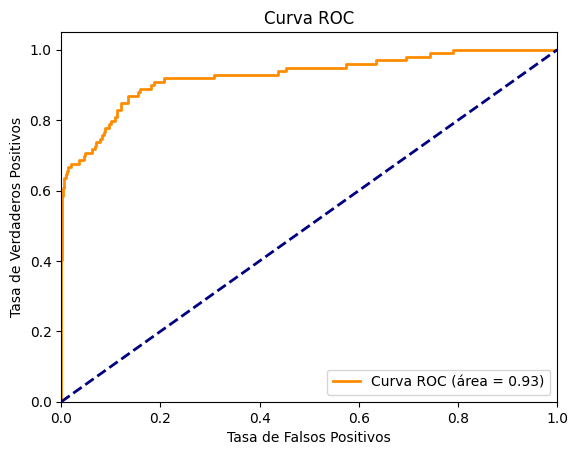

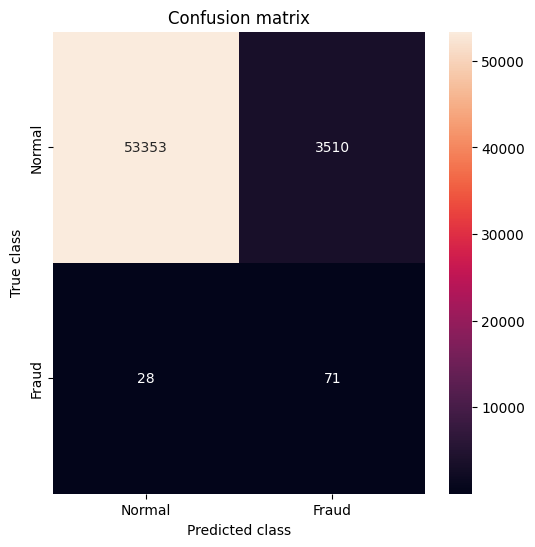


% de transacciones etiquetadas como fraude que fueron correctas (precisión): 71/(3510+71) = 1.98%
% de transacciones fraudulentas que fueron detectadas con éxito (sensibilidad):    71/(28+71) = 71.72%
% de transacciones normales que fueron identificadas correctamente (especificidad): 53353/(53353+3510) = 93.83%


In [107]:
evaluar_rendimiento_autoencoder_saves_test_v2(vae_v2)